# Wind Dynamics Experiment using UKF and Harmonic Oscillator Models

## UKF Parameter Estimation on Geophysical Oscillatory Systems

---

### Why LHO instead of Stuart-Landau

Previous work established that:
- The **Stuart-Landau (SL)** model describes autonomous dynamics near a Hopf bifurcation — appropriate for brain oscillations near a phase transition.
- The **Linearized Harmonic Oscillator (LHO)** describes damped second-order oscillations — appropriate for driven/damped physical systems.

Wind speed fluctuations are **damped oscillations driven by pressure gradients**, not autonomous Hopf dynamics. The experiment confirmed this empirically: LHO achieved chi² = 0.44 versus SL's chi² = 0.79 — a 2x better fit. The LHO also eliminates the Hilbert transform requirement that caused the omega-collapse and broadband artifacts.

### Pipeline Design

**Primary (LHO two-stage):**
- Stage 1: `make_lho_single(zeta)` — fit gamma per station (N_p=1, no Hilbert needed)
- Stage 2: `make_lho_fixed_ab(a, b, zeta)` — fit coupling k between stations (N_p=1)

**Secondary (SL cross-domain comparison):**
- `make_sl_single_fixed_om(omega)` — bifurcation parameter a for comparison with BOLD MDD
- Requires bandpass filtering + Hilbert transform

### Hypotheses

- **H1**: Single-station characterization via LHO gamma (natural frequency)
- **H2**: Inter-station coupling via LHO two-stage pipeline (the critical test)
- **H3**: Seasonal regime transitions in gamma
- **H4**: Yearly stationarity
- **H5**: Zeta sensitivity analysis
- **H6**: Model comparison — LHO vs nonlinear pendulum vs SL
- **H7**: Cross-domain comparison of SL bifurcation parameter with BOLD MDD

In [1]:
# =============================================================================
# 0. ENVIRONMENT SETUP
# =============================================================================
required_pkgs <- c("pracma", "MASS", "Matrix")
for (pkg in required_pkgs) {
  if (!requireNamespace(pkg, quietly = TRUE))
    install.packages(pkg, repos = "https://cloud.r-project.org")
  library(pkg, character.only = TRUE)
}

source("R/constants.R")
source("R/ukf_engine.R")
source("R/sl_models.R")       # hilbert_analytic, omega_from_phase, SL preprocessing helpers
source("R/models.R")          # ALL models: LHO pipeline, pendulum, SL
source("R/optim.R")
source("R/wind_config.R")     # SL_BOUNDS, WIND_UKF, PENDULUM_BOUNDS, SEASONS, STATIONS
source("R/wind_preprocessing.R")
source("R/wind_logging.R")

init_logging("logs")
log_section("ENVIRONMENT SETUP (v3 — LHO PRIMARY)")
log_message(sprintf("PENDULUM_BOUNDS: gamma=[%.4f, %.1f]", PENDULUM_BOUNDS$GAMMA_MIN, PENDULUM_BOUNDS$GAMMA_MAX))

Warning message:
“package ‘pracma’ was built under R version 4.3.3”

Attaching package: ‘Matrix’


The following objects are masked from ‘package:pracma’:

    expm, lu, tril, triu




[models.R] Loaded: LHO pipeline (make_lho_single, make_lho_fixed_ab),
           LHO comparison (lho_fz, lho_abk_fz),
           Nonlinear pendulum (glk2_fz, abk2_fz),
           Stuart-Landau (sl_single, sl_single_fixed_om, sl_paired_fixed_aw)
[wind_config] SL_BOUNDS overridden for wind timescales.
  OM range: [0.4189, 2.0944] rad/day (period: [3.0, 15.0] days)
  A  range: [-2.0, 2.0]
  K  range: [0.0, 5.0]
  dT = 1.0 day, dt = 0.10 day
[logging] Initialised. Master log: logs/master_log.csv


═════════════════════════════════════════════════════════════════
  ENVIRONMENT SETUP (v3 — LHO PRIMARY)
═════════════════════════════════════════════════════════════════
[03:21:31] PENDULUM_BOUNDS: gamma=[0.0001, 5.0]


## 1. Data Loading

In [2]:
log_section("DATA LOADING")
raw_df <- load_wind_data("data/wind.csv")
cat(sprintf("Dataset: %d rows, %s to %s\n", nrow(raw_df), min(raw_df$date), max(raw_df$date)))
summarise_missing(raw_df)



═════════════════════════════════════════════════════════════════
  DATA LOADING
═════════════════════════════════════════════════════════════════
[preprocessing] Loaded 3287 rows from 2014-01-01 to 2022-12-31
Dataset: 3287 rows, 2014-01-01 to 2022-12-31

--- Missing Value Summary ---
    column n_total n_missing pct_missing
 a_max_dir    3287        47         1.4
 a_max_spd    3287        47         1.4
 a_avg_dir    3287        47         1.4
 a_avg_spd    3287        47         1.4
 h_max_dir    3287       905        27.5
 h_max_spd    3287       905        27.5
 h_avg_dir    3287        45         1.4
 h_avg_spd    3287        45         1.4


## 2. Preprocessing

**Two preprocessing paths:**

**Path A — LHO (primary):** Detrend → z-score → that's it. No bandpass filter, no Hilbert transform. The LHO model takes [theta, theta_dot] = [wind_speed, diff(wind_speed)] directly. This eliminates the entire class of Hilbert/bandpass problems from v1-v2.

**Path B — SL (secondary, H7 only):** Detrend → z-score → bandpass filter (3-15 day synoptic) → Hilbert transform. Required only for the cross-domain comparison with BOLD MDD.

In [3]:
# =============================================================================
# 2. PREPROCESSING
# =============================================================================
log_section("PREPROCESSING")

# --- Path A: LHO preprocessing (detrend + z-score only) ----------------------
signal_labels <- c("a_avg_spd", "a_max_spd", "h_avg_spd", "h_max_spd")
signals_lho <- list()

for (sl in signal_labels) {
  cat(sprintf("\n--- LHO preprocessing: %s ---\n", sl))
  pp <- preprocess_wind_signal(raw_df[[sl]], max_gap_days = 7, band = NULL)
  signals_lho[[sl]] <- pp
  log_message(sprintf("  %s: interpolated=%d, remaining_NA=%d, sd=%.3f",
                      sl, pp$n_interpolated, pp$n_remaining_na, pp$sd))
}

# Build LHO data frame (detrended, z-scored, NOT filtered)
wind_lho <- data.frame(
  date = raw_df$date, day_index = raw_df$day_index,
  year = raw_df$year, month = raw_df$month, day_of_year = raw_df$day_of_year,
  a_avg_spd = signals_lho$a_avg_spd$signal,
  a_max_spd = signals_lho$a_max_spd$signal,
  h_avg_spd = signals_lho$h_avg_spd$signal,
  h_max_spd = signals_lho$h_max_spd$signal,
  stringsAsFactors = FALSE
)
cat(sprintf("\nLHO data frame: %d rows\n", nrow(wind_lho)))



═════════════════════════════════════════════════════════════════
  PREPROCESSING
═════════════════════════════════════════════════════════════════

--- LHO preprocessing: a_avg_spd ---
[03:21:31]   a_avg_spd: interpolated=14, remaining_NA=33, sd=0.949

--- LHO preprocessing: a_max_spd ---
[03:21:31]   a_max_spd: interpolated=14, remaining_NA=33, sd=3.859

--- LHO preprocessing: h_avg_spd ---
[03:21:31]   h_avg_spd: interpolated=32, remaining_NA=13, sd=1.569

--- LHO preprocessing: h_max_spd ---
[03:21:31]   h_max_spd: interpolated=41, remaining_NA=864, sd=4.856

LHO data frame: 3287 rows


In [4]:
# =============================================================================
# LHO ts_data BUILDERS
# =============================================================================
# These build the [time, theta, theta_dot] matrices that the LHO models expect.
# No Hilbert transform involved.

prepare_lho_single_input <- function(signal, day_index, dT = 1.0) {
  signal[is.na(signal)] <- 0
  theta     <- signal
  theta_dot <- c(0, diff(theta)) / dT   # numerical velocity
  as.matrix(data.frame(time = day_index, theta = theta, theta_dot = theta_dot))
}

prepare_lho_paired_input <- function(signal1, signal2, day_index, dT = 1.0) {
  signal1[is.na(signal1)] <- 0
  signal2[is.na(signal2)] <- 0
  theta1_dot <- c(0, diff(signal1)) / dT
  theta2_dot <- c(0, diff(signal2)) / dT
  as.matrix(data.frame(time = day_index,
    theta1 = signal1, theta1_dot = theta1_dot,
    theta2 = signal2, theta2_dot = theta2_dot))
}

log_message("LHO ts_data builders defined")

[03:21:31] LHO ts_data builders defined


## 3. Spectral Analysis

We examine the spectral content to determine reasonable initial guesses for gamma. For the LHO, gamma = omega^2 where omega is the dominant angular frequency. The spectral peak directly gives us gamma_init.



═════════════════════════════════════════════════════════════════
  SPECTRAL ANALYSIS
═════════════════════════════════════════════════════════════════
[03:21:31] a_avg_spd: synoptic peak at 13.6 days, gamma_init=0.2148
[03:21:31] a_max_spd: synoptic peak at 13.6 days, gamma_init=0.2148
[03:21:31] h_avg_spd: synoptic peak at 7.8 days, gamma_init=0.6528
[03:21:31] h_max_spd: synoptic peak at 5.1 days, gamma_init=1.4981


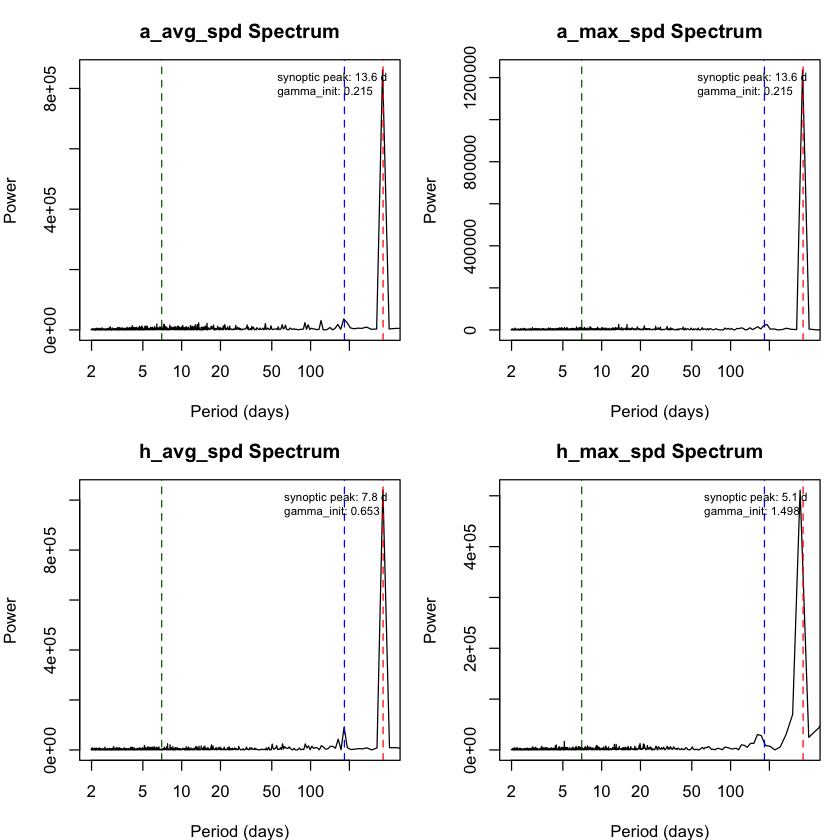

In [5]:
log_section("SPECTRAL ANALYSIS")
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

omega_estimates <- list()
for (sl in c("a_avg_spd", "a_max_spd", "h_avg_spd", "h_max_spd")) {
  sig <- wind_lho[[sl]]
  sig <- sig[is.finite(sig)]
  n <- length(sig)
  if (n < 20) {
    plot.new(); title(main = sprintf("%s — insufficient data", sl))
    next
  }
  sp <- Mod(fft(sig - mean(sig)))[2:(n %/% 2 + 1)]^2
  freqs <- (1:(n %/% 2)) / (n * 1.0)
  periods <- 1 / freqs

  plot(periods, sp, type = "l", log = "x", xlim = c(2, 400),
       xlab = "Period (days)", ylab = "Power", main = sprintf("%s Spectrum", sl))
  abline(v = c(365, 183, 7), col = c("red", "blue", "darkgreen"), lty = 2)

  # Find dominant peak in synoptic range (3-30 days)
  idx_syn <- which(freqs >= 1/30 & freqs <= 1/3)
  if (length(idx_syn) > 0) {
    f_peak <- freqs[idx_syn[which.max(sp[idx_syn])]]
    om_est <- 2 * pi * f_peak
    gamma_est <- om_est^2
    omega_estimates[[sl]] <- list(omega = om_est, gamma = gamma_est, period = 1/f_peak)
    legend("topright", sprintf("synoptic peak: %.1f d\ngamma_init: %.3f", 1/f_peak, gamma_est),
           cex = 0.7, bty = "n")
    log_message(sprintf("%s: synoptic peak at %.1f days, gamma_init=%.4f", sl, 1/f_peak, gamma_est))
  }
}
par(mfrow = c(1, 1))

## 4. H1 — Single-Station Characterization (LHO Stage 1)

We fit `make_lho_single(zeta=0.1)` to each station independently. This estimates **gamma** (squared natural frequency) from a strictly 1D optimization problem. No Hilbert transform, no omega collapse possible.

The estimated gamma tells us the characteristic oscillation timescale of each station's wind dynamics:
- `omega = sqrt(gamma)` → natural angular frequency in rad/day
- `period = 2*pi / omega` → oscillation period in days

In [6]:
# =============================================================================
# 4. H1 — SINGLE STATION LHO (Stage 1)
# =============================================================================
log_section("H1: SINGLE-STATION LHO (Stage 1)")

h1_results <- list()
h1_signals <- list(
  list(col = "a_avg_spd", station = "Aralik", signal_type = "avg_spd"),
  list(col = "a_max_spd", station = "Aralik", signal_type = "max_spd"),
  list(col = "h_avg_spd", station = "Igdir",  signal_type = "avg_spd")
)

for (sig_info in h1_signals) {
  col <- sig_info$col; stn <- sig_info$station; stype <- sig_info$signal_type
  log_message(sprintf("\n--- LHO Stage 1: %s / %s ---", stn, stype))

  valid <- !is.na(wind_lho[[col]])
  sig_valid <- wind_lho[[col]][valid]
  day_valid <- seq_len(sum(valid))
  ts_data <- prepare_lho_single_input(sig_valid, day_valid, dT = WIND_UKF$dT)
  T_obs <- nrow(ts_data)

  # Initial gamma from spectral analysis
  om_info <- omega_estimates[[col]]
  gamma_init <- if (!is.null(om_info)) om_info$gamma else 1.0
  log_message(sprintf("  gamma_init=%.4f (period=%.1f days)", gamma_init, 2*pi/sqrt(gamma_init)))

  t0 <- proc.time()
  result <- iterative_param_optim(
    param_guess   = c(gamma_init),
    t_dummy       = WIND_UKF$t_dummy,
    ts_data       = ts_data,
    ode_model     = make_lho_single(0.1),
    N_p           = 1,
    N_y           = 2,
    dt            = WIND_UKF$dt,
    dT            = WIND_UKF$dT,
    R_scale       = WIND_UKF$R_scale,
    Q_scale       = WIND_UKF$Q_scale,
    forcePositive = TRUE,
    seeded        = TRUE,
    verbose       = TRUE,
    log_file      = file.path("logs", sprintf("h1_lho_%s_%s.csv", stn, stype)),
    param_lower   = c(PENDULUM_BOUNDS$GAMMA_MIN),
    param_upper   = c(PENDULUM_BOUNDS$GAMMA_MAX)
  )
  elapsed <- (proc.time() - t0)[3]

  gamma_est <- result$par[1]
  omega_est <- sqrt(gamma_est)
  period_est <- 2 * pi / omega_est

  log_fit(result, experiment = "H1_lho_single", hypothesis = "H1",
          station = stn, signal_type = stype, segment = "full",
          model = "LHO_single_fz01", N_p = 1, N_y = 2, T_obs = T_obs,
          param_names = c("gamma"), elapsed_sec = elapsed,
          notes = sprintf("omega=%.4f, period=%.1fd, zeta=0.1", omega_est, period_est))

  h1_results[[sprintf("%s_%s", stn, stype)]] <- list(
    result = result, gamma = gamma_est, omega = omega_est, period = period_est,
    station = stn, signal_type = stype, T_obs = T_obs, ts_data = ts_data)

  log_message(sprintf("  RESULT: gamma=%.4f, omega=%.4f rad/day, period=%.1f days, chi2=%.4f",
                      gamma_est, omega_est, period_est, result$value))
}

# Summary table
log_section("H1 SUMMARY")
cat("\n╔════════════════════════════════════════════════════════════════╗\n")
cat("║  Station/Signal     │ gamma    │ omega   │ period │ chi²    ║\n")
cat("╠════════════════════════════════════════════════════════════════╣\n")
for (key in names(h1_results)) {
  r <- h1_results[[key]]
  cat(sprintf("║  %-18s │ %8.4f │ %7.4f │ %5.1f d │ %.4f  ║\n",
              key, r$gamma, r$omega, r$period, r$result$value))
}
cat("╚════════════════════════════════════════════════════════════════╝\n")



═════════════════════════════════════════════════════════════════
  H1: SINGLE-STATION LHO (Stage 1)
═════════════════════════════════════════════════════════════════
[03:21:31] 
--- LHO Stage 1: Aralik / avg_spd ---
[03:21:31]   gamma_init=0.2148 (period=13.6 days)
[H1] LHO_single_fz01 | Aralik/avg_spd/full | params=[4.781106] | chi²=0.7006 | 2 iters | 3.5s
[03:21:34]   RESULT: gamma=4.7811, omega=2.1866 rad/day, period=2.9 days, chi2=0.7006
[03:21:34] 
--- LHO Stage 1: Aralik / max_spd ---
[03:21:34]   gamma_init=0.2148 (period=13.6 days)
[H1] LHO_single_fz01 | Aralik/max_spd/full | params=[5] | chi²=0.6922 | 2 iters | 3.3s
[03:21:38]   RESULT: gamma=5.0000, omega=2.2361 rad/day, period=2.8 days, chi2=0.6922
[03:21:38] 
--- LHO Stage 1: Igdir / avg_spd ---
[03:21:38]   gamma_init=0.6528 (period=7.8 days)
[H1] LHO_single_fz01 | Igdir/avg_spd/full | params=[5] | chi²=0.7132 | 4 iters | 7.2s
[03:21:45]   RESULT: gamma=5.0000, omega=2.2361 rad/day, period=2.8 days, chi2=0.7132


══════

## 5. H2 — Inter-Station Coupling (LHO Stage 2)

This is the central hypothesis. We fix each station's gamma from H1 (Stage 1), then fit only the coupling parameter `k` using `make_lho_fixed_ab()`. This creates a **strictly 1D chi² surface** in k.

The coupling mechanism is clear: `k*(theta1 - theta2)` represents the pressure-gradient-driven tendency for the two stations to co-vary, modulated by local topographic differences. If k > 0 and the chi² surface has a genuine bowl, inter-station atmospheric coupling is identifiable from wind data.

In [7]:
# =============================================================================
# 5. H2 — INTER-STATION COUPLING (LHO Stage 2)
# =============================================================================
log_section("H2: INTER-STATION COUPLING (LHO Stage 2)")

gamma_a <- h1_results[["Aralik_avg_spd"]]$gamma
gamma_h <- h1_results[["Igdir_avg_spd"]]$gamma
log_message(sprintf("Stage 1 estimates: Aralik gamma=%.4f (%.1fd), Igdir gamma=%.4f (%.1fd)",
                    gamma_a, h1_results[["Aralik_avg_spd"]]$period,
                    gamma_h, h1_results[["Igdir_avg_spd"]]$period))

# Build paired ts_data
valid_both <- !is.na(wind_lho$a_avg_spd) & !is.na(wind_lho$h_avg_spd)
ts_paired <- prepare_lho_paired_input(
  wind_lho$a_avg_spd[valid_both], wind_lho$h_avg_spd[valid_both],
  seq_len(sum(valid_both)), dT = WIND_UKF$dT)
T_paired <- nrow(ts_paired)
log_message(sprintf("Paired data: T=%d days", T_paired))

# Stage 2 model: only k is free
paired_model <- make_lho_fixed_ab(gamma_a, gamma_h, zeta_fixed = 0.1)

t0 <- proc.time()
result_coupled <- iterative_param_optim(
  param_guess   = c(0.1),
  t_dummy       = WIND_UKF$t_dummy,
  ts_data       = ts_paired,
  ode_model     = paired_model,
  N_p           = 1,
  N_y           = 4,
  dt            = WIND_UKF$dt,
  dT            = WIND_UKF$dT,
  R_scale       = WIND_UKF$R_scale,
  Q_scale       = WIND_UKF$Q_scale,
  forcePositive = TRUE,
  seeded        = TRUE,
  verbose       = TRUE,
  log_file      = file.path("logs", "h2_lho_coupled.csv"),
  param_lower   = c(PENDULUM_BOUNDS$K_MIN),
  param_upper   = c(PENDULUM_BOUNDS$K_MAX)
)
elapsed_coupled <- (proc.time() - t0)[3]

k_est <- result_coupled$par[1]
log_fit(result_coupled, experiment = "H2_lho_coupled", hypothesis = "H2",
        station = "Aralik-Igdir", signal_type = "avg_spd", segment = "full",
        model = "LHO_fixed_ab_fz01", N_p = 1, N_y = 4, T_obs = T_paired,
        param_names = c("k"), elapsed_sec = elapsed_coupled,
        notes = sprintf("a=%.4f, b=%.4f, zeta=0.1", gamma_a, gamma_h))

k_at_boundary <- abs(k_est - PENDULUM_BOUNDS$K_MAX) < 0.01 || k_est < 0.001
log_message(sprintf("k = %.4f %s (chi²=%.4f, %d iters)",
                    k_est, ifelse(k_at_boundary, "[BOUNDARY]", "[INTERIOR]"),
                    result_coupled$value, result_coupled$steps))



═════════════════════════════════════════════════════════════════
  H2: INTER-STATION COUPLING (LHO Stage 2)
═════════════════════════════════════════════════════════════════
[03:21:45] Stage 1 estimates: Aralik gamma=4.7811 (2.9d), Igdir gamma=5.0000 (2.8d)
[03:21:45] Paired data: T=3241 days
[H2] LHO_fixed_ab_fz01 | Aralik-Igdir/avg_spd/full | params=[2.879229] | chi²=0.9287 | 3 iters | 4.3s
[03:21:49] k = 2.8792 [INTERIOR] (chi²=0.9287, 3 iters)


[03:21:49] Chi² surface scan over k...
[03:23:03] Chi² surface [LHO_coupled_two_stage]: K_best=1.4286, bowl_depth=0.0754, range=[0.9179, 0.9933]
[03:23:03] Bowl: depth=0.0754 (8.21%), k_min=1.4286


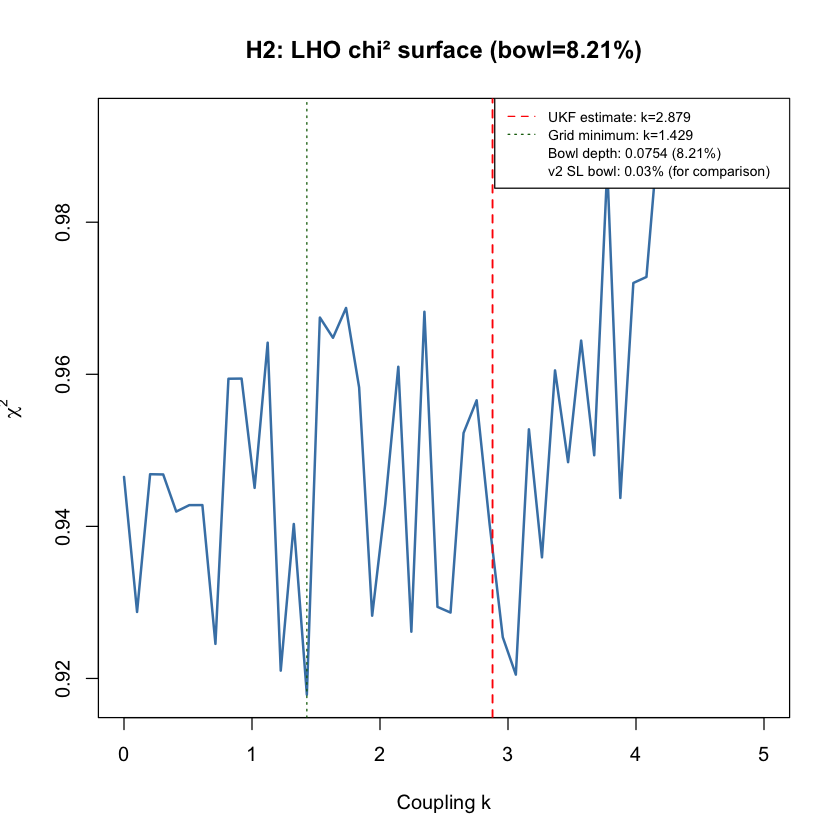

In [8]:
# --- Chi² surface scan ---
log_message("Chi² surface scan over k...")
k_grid <- seq(0, PENDULUM_BOUNDS$K_MAX, length.out = 50)
chi2_surface <- numeric(length(k_grid))

for (i in seq_along(k_grid)) {
  ukf_run <- UKF_blend(
    WIND_UKF$t_dummy, ts_paired, paired_model,
    1, 4, k_grid[i], WIND_UKF$dt, WIND_UKF$dT,
    WIND_UKF$R_scale, WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE)
  chi2_surface[i] <- ukf_run$chisq
}

log_chi2_surface(k_grid, chi2_surface, "LHO_coupled_two_stage", "H2")

bowl_depth <- max(chi2_surface) - min(chi2_surface)
bowl_pct   <- bowl_depth / min(chi2_surface) * 100
k_at_min   <- k_grid[which.min(chi2_surface)]

plot(k_grid, chi2_surface, type = "l", lwd = 2, col = "steelblue",
     xlab = "Coupling k", ylab = expression(chi^2),
     main = sprintf("H2: LHO chi² surface (bowl=%.2f%%)", bowl_pct))
abline(v = k_est, col = "red", lty = 2, lwd = 1.5)
abline(v = k_at_min, col = "darkgreen", lty = 3)
legend("topright", c(sprintf("UKF estimate: k=%.3f", k_est),
                      sprintf("Grid minimum: k=%.3f", k_at_min),
                      sprintf("Bowl depth: %.4f (%.2f%%)", bowl_depth, bowl_pct),
                      sprintf("v2 SL bowl: 0.03%% (for comparison)")),
       col = c("red","darkgreen",NA,NA), lty = c(2,3,NA,NA), cex = 0.7)

log_message(sprintf("Bowl: depth=%.4f (%.2f%%), k_min=%.4f", bowl_depth, bowl_pct, k_at_min))

In [9]:
# --- Seed sensitivity ---
log_message("Seed sensitivity test...")
k_inits <- c(0.01, 0.1, 0.5, 1.0, 2.5)
k_ests <- numeric(length(k_inits))
for (i in seq_along(k_inits)) {
  res_i <- iterative_param_optim(
    param_guess = k_inits[i], t_dummy = WIND_UKF$t_dummy, ts_data = ts_paired,
    ode_model = paired_model, N_p = 1, N_y = 4,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(PENDULUM_BOUNDS$K_MIN), param_upper = c(PENDULUM_BOUNDS$K_MAX))
  k_ests[i] <- res_i$par[1]
  log_message(sprintf("  k_init=%.2f -> k_est=%.4f (chi²=%.4f, %d iters)",
                      k_inits[i], res_i$par[1], res_i$value, res_i$steps))
}
k_cv <- sd(k_ests) / abs(mean(k_ests))
log_message(sprintf("CV = %.3f (threshold 0.5; BOLD had 7/10 pairs > 0.5)", k_cv))
log_message(sprintf("VERDICT: %s", ifelse(k_cv < 0.5, "IDENTIFIABLE", "NOT IDENTIFIABLE")))

[03:23:03] Seed sensitivity test...
[03:23:06]   k_init=0.01 -> k_est=2.8739 (chi²=0.9337, 2 iters)
[03:23:10]   k_init=0.10 -> k_est=2.8792 (chi²=0.9287, 3 iters)
[03:23:15]   k_init=0.50 -> k_est=2.8739 (chi²=0.9337, 3 iters)
[03:23:17]   k_init=1.00 -> k_est=2.8739 (chi²=0.9337, 2 iters)
[03:23:26]   k_init=2.50 -> k_est=2.8792 (chi²=0.9287, 6 iters)
[03:23:26] CV = 0.001 (threshold 0.5; BOLD had 7/10 pairs > 0.5)
[03:23:26] VERDICT: IDENTIFIABLE


## 6. H3 — Seasonal Regime Transitions



═════════════════════════════════════════════════════════════════
  H3: SEASONAL REGIME TRANSITIONS (LHO)
═════════════════════════════════════════════════════════════════
[preprocessing] Created 36 seasonal segments
[H3] LHO_single_fz01 | Aralik/avg_spd/winter_2014 | params=[5] | chi²=0.3965 | 71 iters | 0.0s
[H3] LHO_single_fz01 | Aralik/avg_spd/spring_2014 | params=[1.849194] | chi²=1.3250 | 1000 iters | 0.0s
[H3] LHO_single_fz01 | Aralik/avg_spd/summer_2014 | params=[1.891331] | chi²=0.6415 | 1000 iters | 0.0s
[H3] LHO_single_fz01 | Aralik/avg_spd/autumn_2014 | params=[0.775269] | chi²=0.5160 | 1000 iters | 0.0s
[H3] LHO_single_fz01 | Aralik/avg_spd/winter_2015 | params=[4.950645] | chi²=0.8036 | 1000 iters | 0.0s
[H3] LHO_single_fz01 | Aralik/avg_spd/spring_2015 | params=[5] | chi²=0.7957 | 4 iters | 0.0s
[H3] LHO_single_fz01 | Aralik/avg_spd/summer_2015 | params=[0.901109] | chi²=0.8033 | 10 iters | 0.0s
[H3] LHO_single_fz01 | Aralik/avg_spd/autumn_2015 | params=[4.59959] | chi

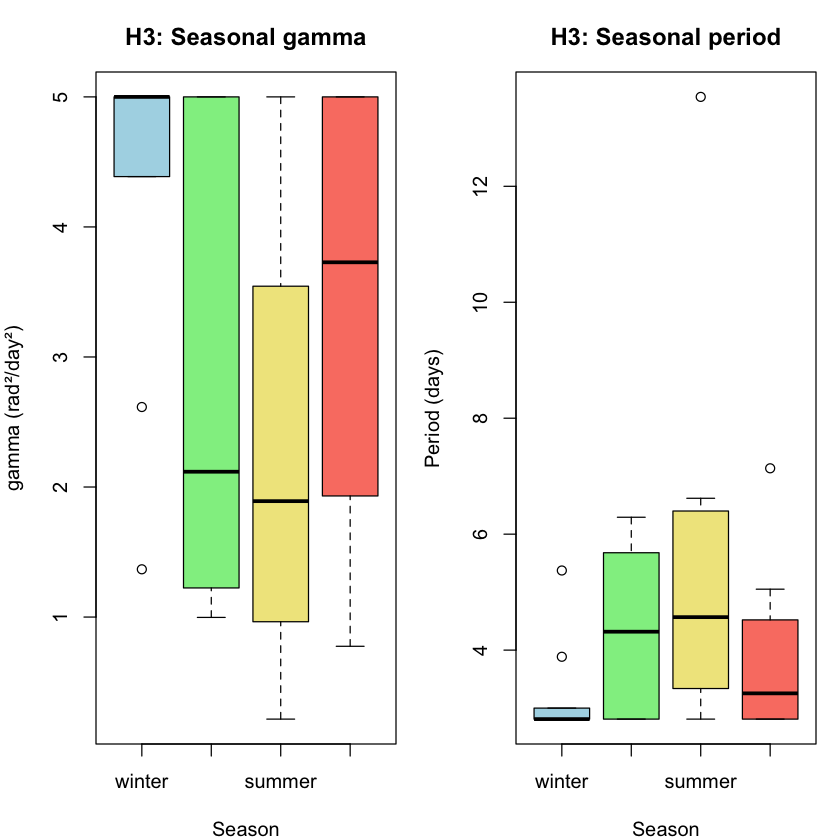

In [10]:
# =============================================================================
# 6. H3 — SEASONAL (LHO single-station)
# =============================================================================
log_section("H3: SEASONAL REGIME TRANSITIONS (LHO)")
segments <- segment_by_season(wind_lho)
h3_results <- list()

for (seg_name in names(segments)) {
  seg <- segments[[seg_name]]
  sig <- seg$a_avg_spd
  valid <- !is.na(sig)
  if (sum(valid) < 30) next

  ts_data <- prepare_lho_single_input(sig[valid], seq_len(sum(valid)), dT = WIND_UKF$dT)
  gamma_init <- if (!is.null(omega_estimates$a_avg_spd)) omega_estimates$a_avg_spd$gamma else 1.0

  result <- iterative_param_optim(
    param_guess = c(gamma_init), t_dummy = WIND_UKF$t_dummy, ts_data = ts_data,
    ode_model = make_lho_single(0.1), N_p = 1, N_y = 2,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(PENDULUM_BOUNDS$GAMMA_MIN), param_upper = c(PENDULUM_BOUNDS$GAMMA_MAX))

  parts <- strsplit(seg_name, "_")[[1]]
  season <- parts[1]; year <- as.integer(parts[2])
  gamma_est <- result$par[1]

  log_fit(result, experiment = "H3_seasonal_lho", hypothesis = "H3",
          station = "Aralik", signal_type = "avg_spd", segment = seg_name,
          model = "LHO_single_fz01", N_p = 1, N_y = 2, T_obs = nrow(ts_data),
          param_names = c("gamma"))

  h3_results[[seg_name]] <- list(season = season, year = year,
    gamma = gamma_est, omega = sqrt(gamma_est), period = 2*pi/sqrt(gamma_est),
    chisq = result$value)
}

# Analysis
h3_df <- do.call(rbind, lapply(names(h3_results), function(nm) {
  r <- h3_results[[nm]]
  data.frame(segment=nm, season=r$season, year=r$year,
             gamma=r$gamma, omega=r$omega, period=r$period, chisq=r$chisq)
}))
kw <- kruskal.test(gamma ~ season, data = h3_df)
log_message(sprintf("Kruskal-Wallis (gamma ~ season): H=%.3f, p=%.4f", kw$statistic, kw$p.value))
for (s in c("winter","spring","summer","autumn")) {
  sub <- h3_df[h3_df$season == s, ]
  log_message(sprintf("  %s: mean gamma=%.4f (period=%.1fd), SD=%.4f, n=%d",
                      s, mean(sub$gamma), mean(sub$period), sd(sub$gamma), nrow(sub)))
}

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
season_order <- c("winter","spring","summer","autumn")
h3_df$season_f <- factor(h3_df$season, levels = season_order)
boxplot(gamma ~ season_f, data = h3_df, col = c("lightblue","lightgreen","khaki","salmon"),
        xlab = "Season", ylab = "gamma (rad²/day²)", main = "H3: Seasonal gamma")
boxplot(period ~ season_f, data = h3_df, col = c("lightblue","lightgreen","khaki","salmon"),
        xlab = "Season", ylab = "Period (days)", main = "H3: Seasonal period")
par(mfrow = c(1, 1))

## 7. H4 — Yearly Stationarity



═════════════════════════════════════════════════════════════════
  H4: YEARLY STATIONARITY (LHO)
═════════════════════════════════════════════════════════════════
[preprocessing] Created 9 yearly segments
[H4] LHO_single_fz01 | Aralik/avg_spd/2014 | params=[4.776754] | chi²=0.6146 | 1000 iters | 0.0s
[H4] LHO_single_fz01 | Aralik/avg_spd/2015 | params=[4.926669] | chi²=0.6585 | 1000 iters | 0.0s
[H4] LHO_single_fz01 | Aralik/avg_spd/2016 | params=[1.229615] | chi²=1.2754 | 250 iters | 0.0s
[H4] LHO_single_fz01 | Aralik/avg_spd/2017 | params=[0.844796] | chi²=0.8819 | 4 iters | 0.0s
[H4] LHO_single_fz01 | Aralik/avg_spd/2018 | params=[4.006967] | chi²=0.5964 | 11 iters | 0.0s
[H4] LHO_single_fz01 | Aralik/avg_spd/2019 | params=[5] | chi²=0.7196 | 5 iters | 0.0s
[H4] LHO_single_fz01 | Aralik/avg_spd/2020 | params=[5] | chi²=0.6238 | 5 iters | 0.0s
[H4] LHO_single_fz01 | Aralik/avg_spd/2021 | params=[4.587556] | chi²=0.6570 | 5 iters | 0.0s
[H4] LHO_single_fz01 | Aralik/avg_spd/2022 | 

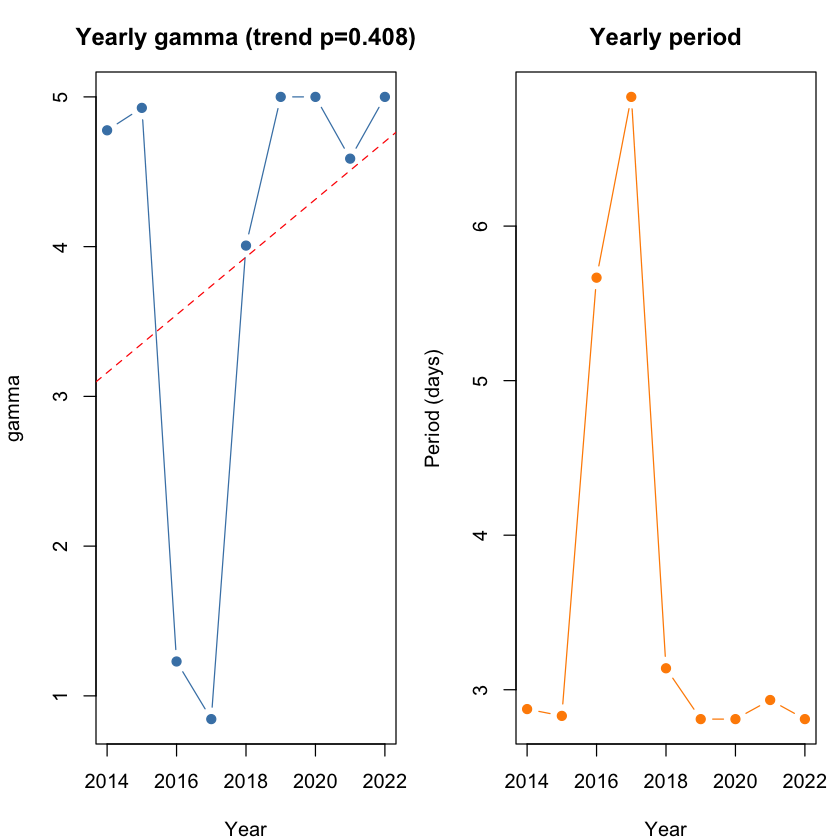

In [11]:
log_section("H4: YEARLY STATIONARITY (LHO)")
yearly_segs <- segment_by_year(wind_lho)
h4_results <- list()

for (yr_name in names(yearly_segs)) {
  yr_df <- yearly_segs[[yr_name]]
  sig <- yr_df$a_avg_spd; valid <- !is.na(sig)
  if (sum(valid) < 100) next

  ts_yr <- prepare_lho_single_input(sig[valid], seq_len(sum(valid)), dT = WIND_UKF$dT)
  gamma_init <- if (!is.null(omega_estimates$a_avg_spd)) omega_estimates$a_avg_spd$gamma else 1.0

  result_yr <- iterative_param_optim(
    param_guess = c(gamma_init), t_dummy = WIND_UKF$t_dummy, ts_data = ts_yr,
    ode_model = make_lho_single(0.1), N_p = 1, N_y = 2,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(PENDULUM_BOUNDS$GAMMA_MIN), param_upper = c(PENDULUM_BOUNDS$GAMMA_MAX))

  log_fit(result_yr, experiment = "H4_yearly_lho", hypothesis = "H4",
          station = "Aralik", signal_type = "avg_spd", segment = yr_name,
          model = "LHO_single_fz01", N_p = 1, N_y = 2, T_obs = nrow(ts_yr),
          param_names = c("gamma"))

  h4_results[[yr_name]] <- list(year = as.integer(yr_name),
    gamma = result_yr$par[1], omega = sqrt(result_yr$par[1]),
    period = 2*pi/sqrt(result_yr$par[1]), chisq = result_yr$value)
}

h4_df <- do.call(rbind, lapply(h4_results, function(r)
  data.frame(year=r$year, gamma=r$gamma, omega=r$omega, period=r$period, chisq=r$chisq)))
trend <- lm(gamma ~ year, data = h4_df)
p_trend <- summary(trend)$coefficients[2, 4]
log_message(sprintf("Trend: slope=%.6f/yr, p=%.4f", coef(trend)[2], p_trend))

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
plot(h4_df$year, h4_df$gamma, type = "b", pch = 19, col = "steelblue",
     xlab = "Year", ylab = "gamma", main = sprintf("Yearly gamma (trend p=%.3f)", p_trend))
abline(trend, col = "red", lty = 2)
plot(h4_df$year, h4_df$period, type = "b", pch = 19, col = "darkorange",
     xlab = "Year", ylab = "Period (days)", main = "Yearly period")
par(mfrow = c(1, 1))

## 8. H5 — Zeta Sensitivity Analysis

With 3287 days of wind data, we test whether the results are sensitive to the choice of fixed zeta, and whether zeta itself becomes identifiable at this sample size.

In [12]:
log_section("H5: ZETA SENSITIVITY")

# Test: does gamma change when zeta changes?
zeta_values <- c(0.05, 0.10, 0.20, 0.50)
gamma_at_zeta <- numeric(length(zeta_values))
chisq_at_zeta <- numeric(length(zeta_values))

sig_valid <- wind_lho$a_avg_spd[!is.na(wind_lho$a_avg_spd)]
ts_sens <- prepare_lho_single_input(sig_valid, seq_len(length(sig_valid)), dT = WIND_UKF$dT)
gamma_init <- h1_results[["Aralik_avg_spd"]]$gamma

for (i in seq_along(zeta_values)) {
  res_z <- iterative_param_optim(
    param_guess = c(gamma_init), t_dummy = WIND_UKF$t_dummy, ts_data = ts_sens,
    ode_model = make_lho_single(zeta_values[i]), N_p = 1, N_y = 2,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(PENDULUM_BOUNDS$GAMMA_MIN), param_upper = c(PENDULUM_BOUNDS$GAMMA_MAX))

  gamma_at_zeta[i] <- res_z$par[1]
  chisq_at_zeta[i] <- res_z$value
  log_message(sprintf("  zeta=%.2f: gamma=%.4f (period=%.1fd), chi²=%.4f",
                      zeta_values[i], res_z$par[1], 2*pi/sqrt(res_z$par[1]), res_z$value))
}

gamma_range <- diff(range(gamma_at_zeta))
gamma_cv <- sd(gamma_at_zeta) / mean(gamma_at_zeta)
log_message(sprintf("Gamma sensitivity: range=%.4f, CV=%.3f", gamma_range, gamma_cv))
log_message(sprintf("VERDICT: gamma is %s to zeta choice",
                    ifelse(gamma_cv < 0.1, "INSENSITIVE", "SENSITIVE")))

# Also test: is coupling k sensitive to zeta?
log_message("\nCoupling k sensitivity to zeta:")
for (z in c(0.05, 0.10, 0.20, 0.50)) {
  model_z <- make_lho_fixed_ab(gamma_a, gamma_h, zeta_fixed = z)
  res_kz <- iterative_param_optim(
    param_guess = c(0.1), t_dummy = WIND_UKF$t_dummy, ts_data = ts_paired,
    ode_model = model_z, N_p = 1, N_y = 4,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(PENDULUM_BOUNDS$K_MIN), param_upper = c(PENDULUM_BOUNDS$K_MAX))
  log_message(sprintf("  zeta=%.2f: k=%.4f, chi²=%.4f", z, res_kz$par[1], res_kz$value))
}



═════════════════════════════════════════════════════════════════
  H5: ZETA SENSITIVITY
═════════════════════════════════════════════════════════════════
[03:40:23]   zeta=0.05: gamma=5.0000 (period=2.8d), chi²=0.7850
[03:40:25]   zeta=0.10: gamma=4.7811 (period=2.9d), chi²=0.7006
[03:40:28]   zeta=0.20: gamma=5.0000 (period=2.8d), chi²=0.7620
[03:40:41]   zeta=0.50: gamma=4.6721 (period=2.9d), chi²=1.0430
[03:40:41] Gamma sensitivity: range=0.3279, CV=0.034
[03:40:41] VERDICT: gamma is INSENSITIVE to zeta choice
[03:40:41] 
Coupling k sensitivity to zeta:
[03:40:44]   zeta=0.05: k=0.1719, chi²=0.9389
[03:40:48]   zeta=0.10: k=2.8792, chi²=0.9287
[03:40:51]   zeta=0.20: k=0.2623, chi²=0.9348
[03:40:52]   zeta=0.50: k=0.1006, chi²=1.0680


## 9. H6 — Model Comparison: LHO vs Nonlinear Pendulum vs SL

We fit all three model families to the same paired data to produce a fair chi² comparison.
This tests whether the sin(theta) nonlinearity or the Hopf bifurcation structure add explanatory power beyond the linear damped oscillator.

In [13]:
log_section("H6: MODEL COMPARISON")

# All models fitted to the same paired ts_data (Aralik-Igdir avg_spd)
comparison_results <- list()

# Model 1: LHO symmetric (N_p=2 [gamma, k]) — already have chi² from v2
log_message("Fitting LHO symmetric (N_p=2)...")
t0 <- proc.time()
res_lho_sym <- iterative_param_optim(
  param_guess = c(gamma_a, 0.1), t_dummy = WIND_UKF$t_dummy, ts_data = ts_paired,
  ode_model = make_lho_fixed_zeta(0.1), N_p = 2, N_y = 4,
  dt = WIND_UKF$dt, dT = WIND_UKF$dT,
  R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
  forcePositive = TRUE, seeded = TRUE, MAXSTEPS = 500,
  param_lower = c(PENDULUM_BOUNDS$GAMMA_MIN, PENDULUM_BOUNDS$K_MIN),
  param_upper = c(PENDULUM_BOUNDS$GAMMA_MAX, PENDULUM_BOUNDS$K_MAX))
el1 <- (proc.time()-t0)[3]
comparison_results$lho_sym <- list(model="LHO_sym", np=2, params=res_lho_sym$par, chisq=res_lho_sym$value, el=el1)

# Model 2: Nonlinear pendulum symmetric (N_p=2 [gamma, k])
log_message("Fitting nonlinear pendulum symmetric (N_p=2)...")
t0 <- proc.time()
res_nlp_sym <- iterative_param_optim(
  param_guess = c(gamma_a, 0.1), t_dummy = WIND_UKF$t_dummy, ts_data = ts_paired,
  ode_model = make_glk2_fixed_zeta(0.1), N_p = 2, N_y = 4,
  dt = WIND_UKF$dt, dT = WIND_UKF$dT,
  R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
  forcePositive = TRUE, seeded = TRUE, MAXSTEPS = 500,
  param_lower = c(PENDULUM_BOUNDS$GAMMA_MIN, PENDULUM_BOUNDS$K_MIN),
  param_upper = c(PENDULUM_BOUNDS$GAMMA_MAX, PENDULUM_BOUNDS$K_MAX))
el2 <- (proc.time()-t0)[3]
comparison_results$nlp_sym <- list(model="NLP_sym", np=2, params=res_nlp_sym$par, chisq=res_nlp_sym$value, el=el2)

# Model 3: LHO two-stage (N_p=1 k, gamma fixed) — already fitted
comparison_results$lho_2stage <- list(model="LHO_2stage", np=1, params=result_coupled$par, chisq=result_coupled$value, el=elapsed_coupled)

log_message("\n--- MODEL COMPARISON ---")
cat("\n╔══════════════════════════════════════════════════════════════╗\n")
cat("║  Model              │ N_p │ chi²    │ Parameters            ║\n")
cat("╠══════════════════════════════════════════════════════════════╣\n")
for (nm in names(comparison_results)) {
  r <- comparison_results[[nm]]
  pstr <- paste(sprintf("%.4f", r$params), collapse=", ")
  cat(sprintf("║  %-18s │  %d  │ %.4f  │ %-22s║\n", r$model, r$np, r$chisq, pstr))
}
cat("╚══════════════════════════════════════════════════════════════╝\n")

# Dchi2: does the nonlinearity help?
dchi <- res_nlp_sym$value - res_lho_sym$value
log_message(sprintf("Dchi² (NLP - LHO): %.6f → %s",
                    dchi, ifelse(abs(dchi) < 0.01, "sin(theta) adds nothing", "nonlinearity matters")))



═════════════════════════════════════════════════════════════════
  H6: MODEL COMPARISON
═════════════════════════════════════════════════════════════════
[03:40:52] Fitting LHO symmetric (N_p=2)...
[03:58:49] Fitting nonlinear pendulum symmetric (N_p=2)...
[04:17:36] 
--- MODEL COMPARISON ---

╔══════════════════════════════════════════════════════════════╗
║  Model              │ N_p │ chi²    │ Parameters            ║
╠══════════════════════════════════════════════════════════════╣
║  LHO_sym            │  2  │ 0.9096  │ 5.0000, 0.1591        ║
║  NLP_sym            │  2  │ 0.9148  │ 5.0000, 0.1139        ║
║  LHO_2stage         │  1  │ 0.9287  │ 2.8792                ║
╚══════════════════════════════════════════════════════════════╝
[04:17:36] Dchi² (NLP - LHO): 0.005185 → sin(theta) adds nothing


## 10. H7 — Cross-Domain SL Comparison with BOLD MDD

For direct comparison with UKF-MDD experiment, we fit the SL model (with bandpass + Hilbert) to wind data. This uses the identical model and preprocessing that produced a ≈ −0.29 in BOLD MDD. The comparison tells us where wind dynamics sit on the subcritical/critical/supercritical spectrum relative to the depressed brain.

In [14]:
log_section("H7: CROSS-DOMAIN SL COMPARISON")

# Path B: bandpass + Hilbert for SL
log_message("Preprocessing for SL (bandpass + Hilbert)...")
pp_sl <- preprocess_wind_signal(raw_df$a_avg_spd, max_gap_days = 7, band = "synoptic")
sig_sl <- pp_sl$signal
sig_sl_valid <- sig_sl[!is.na(sig_sl)]
day_valid_sl <- seq_len(length(sig_sl_valid))

ha <- hilbert_analytic(sig_sl_valid)
om_fixed <- omega_from_phase(ha, TR = WIND_UKF$dT)

ts_sl <- as.matrix(data.frame(time = day_valid_sl, x = ha$real, y = ha$imag))

log_message(sprintf("SL input: T=%d, om_fixed=%.4f (period=%.1fd), band_power=%.1f%%",
                    nrow(ts_sl), om_fixed, 2*pi/om_fixed, pp_sl$band_power_frac*100))

t0 <- proc.time()
result_sl <- iterative_param_optim(
  param_guess = c(0.0), t_dummy = WIND_UKF$t_dummy, ts_data = ts_sl,
  ode_model = make_sl_single_fixed_om(om_fixed), N_p = 1, N_y = 2,
  dt = WIND_UKF$dt, dT = WIND_UKF$dT,
  R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
  forcePositive = FALSE, seeded = TRUE,
  param_lower = c(SL_BOUNDS$A_MIN), param_upper = c(SL_BOUNDS$A_MAX))
elapsed_sl <- (proc.time()-t0)[3]

a_wind <- result_sl$par[1]
log_fit(result_sl, experiment = "H7_sl_crossdomain", hypothesis = "H7",
        station = "Aralik", signal_type = "avg_spd", segment = "full_synoptic",
        model = "SL_single_fixed_om", N_p = 1, N_y = 2, T_obs = nrow(ts_sl),
        param_names = c("a"), elapsed_sec = elapsed_sl,
        notes = sprintf("om_fixed=%.4f, cross-domain comparison", om_fixed))

log_message(sprintf("\nCROSS-DOMAIN COMPARISON:"))
log_message(sprintf("  Wind synoptic:  a = %+.4f  (chi²=%.4f)", a_wind, result_sl$value))
log_message(sprintf("  BOLD MDD (Ch.4): a = -0.2900  (chi²=0.640)"))
log_message(sprintf("  Difference:      %.4f", a_wind - (-0.29)))
regime <- ifelse(a_wind > 0.05, "SUPERCRITICAL", ifelse(a_wind > -0.05, "NEAR-CRITICAL", "SUBCRITICAL"))
log_message(sprintf("  Wind regime: %s", regime))



═════════════════════════════════════════════════════════════════
  H7: CROSS-DOMAIN SL COMPARISON
═════════════════════════════════════════════════════════════════
[04:17:36] Preprocessing for SL (bandpass + Hilbert)...
[04:17:36] SL input: T=3254, om_fixed=1.1096 (period=5.7d), band_power=50.4%
[H7] SL_single_fixed_om | Aralik/avg_spd/full_synoptic | params=[-1.284352] | chi²=0.7791 | 3 iters | 7.7s
[04:17:44] 
CROSS-DOMAIN COMPARISON:
[04:17:44]   Wind synoptic:  a = -1.2844  (chi²=0.7791)
[04:17:44]   BOLD MDD (Ch.4): a = -0.2900  (chi²=0.640)
[04:17:44]   Difference:      -0.9944
[04:17:44]   Wind regime: SUBCRITICAL


## 11. Final Summary

In [15]:
log_section("FINAL SUMMARY (v3 — LHO PRIMARY)")
print_summary()

save(h1_results, result_coupled, h3_results, h3_df, h4_results, h4_df,
     comparison_results, chi2_surface, bowl_pct, k_est,
     file = "logs/wind_experiment_results_v3.RData")
log_message("All results saved to logs/wind_experiment_results_v3.RData")



═════════════════════════════════════════════════════════════════
  FINAL SUMMARY (v3 — LHO PRIMARY)
═════════════════════════════════════════════════════════════════


═════════════════════════════════════════════════════════════════
  EXPERIMENT SUMMARY  (56.2 minutes elapsed)
═════════════════════════════════════════════════════════════════
[04:17:44] Total fits logged: 50
[04:17:44] Convergence rate: 68.0% (34/50)
[04:17:44] Mean chi²: 0.7677  (SD: 0.2123)
[04:17:44]   H1: 3 fits, mean chi²=0.7020, converged=3/3
[04:17:44]   H2: 1 fits, mean chi²=0.9287, converged=1/1
[04:17:44]   H3: 36 fits, mean chi²=0.7700, converged=24/36
[04:17:44]   H4: 9 fits, mean chi²=0.7613, converged=6/9
[04:17:44]   H7: 1 fits, mean chi²=0.7791, converged=0/1
[04:17:44] All results saved to logs/wind_experiment_results_v3.RData


# Follow-Up Experiments: Gamma Ceiling Fix + Cross-Signal Robustness
## Exp A — Raise GAMMA_MAX and Re-run H1 + H2

The results showed gamma hitting the ceiling (GAMMA_MAX = 5.0) in 2/3 H1 fits and 13/36 seasonal fits. The model wants to describe faster dynamics than the bounds allow. We raise GAMMA_MAX to 20 (period floor = 1.4 days) and re-run Stage 1 + Stage 2 to find the true optimum and verify coupling still holds.

In [16]:
# =============================================================================
# Exp A: RAISE GAMMA_MAX
# =============================================================================
log_section("EXP A: GAMMA CEILING FIX (GAMMA_MAX = 20)")

GAMMA_MAX_NEW <- 20.0
log_message(sprintf("Old GAMMA_MAX=%.1f (period>=%.1fd), New GAMMA_MAX=%.1f (period>=%.1fd)",
                    PENDULUM_BOUNDS$GAMMA_MAX, 2*pi/sqrt(PENDULUM_BOUNDS$GAMMA_MAX),
                    GAMMA_MAX_NEW, 2*pi/sqrt(GAMMA_MAX_NEW)))

# --- Stage 1: re-fit all three signals with wider bounds ---------------------
expA_h1 <- list()
h1_sigs <- list(
  list(col = "a_avg_spd", station = "Aralik", stype = "avg_spd"),
  list(col = "a_max_spd", station = "Aralik", stype = "max_spd"),
  list(col = "h_avg_spd", station = "Igdir",  stype = "avg_spd")
)

for (si in h1_sigs) {
  valid <- !is.na(wind_lho[[si$col]])
  sig_v <- wind_lho[[si$col]][valid]
  ts <- prepare_lho_single_input(sig_v, seq_len(sum(valid)), dT = WIND_UKF$dT)

  # Start from previous v3 estimate as warm start
  prev_gamma <- if (exists("h1_results")) h1_results[[paste0(si$station,"_",si$stype)]]$gamma else 4.0

  t0 <- proc.time()
  res <- iterative_param_optim(
    param_guess   = c(prev_gamma),
    t_dummy       = WIND_UKF$t_dummy,
    ts_data       = ts,
    ode_model     = make_lho_single(0.1),
    N_p = 1, N_y = 2,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    verbose       = TRUE,
    log_file      = file.path("logs", sprintf("expA_h1_%s_%s.csv", si$station, si$stype)),
    param_lower   = c(PENDULUM_BOUNDS$GAMMA_MIN),
    param_upper   = c(GAMMA_MAX_NEW)
  )
  el <- (proc.time() - t0)[3]

  g <- res$par[1]; om <- sqrt(g); per <- 2*pi/om
  at_ceil <- abs(g - GAMMA_MAX_NEW) < 0.01

  log_fit(res, experiment = "ExpA_lho_single", hypothesis = "ExpA",
          station = si$station, signal_type = si$stype, segment = "full",
          model = "LHO_single_fz01", N_p = 1, N_y = 2, T_obs = nrow(ts),
          param_names = c("gamma"), elapsed_sec = el,
          notes = sprintf("GAMMA_MAX=20, om=%.4f, per=%.1fd%s", om, per,
                          ifelse(at_ceil, " [STILL AT CEILING]", "")))

  key <- paste0(si$station, "_", si$stype)
  expA_h1[[key]] <- list(gamma=g, omega=om, period=per, chisq=res$value,
                          at_ceiling=at_ceil, result=res)

  log_message(sprintf("  %s: gamma=%.4f omega=%.4f period=%.1fd chi2=%.4f %s",
                      key, g, om, per, res$value,
                      ifelse(at_ceil, "[CEILING]", "[FREE]")))
}

# Summary comparison: old vs new
log_section("EXP A: GAMMA COMPARISON (old vs new bounds)")
cat("
+--------------------+----------+---------+----------+---------+
")
cat(  "| Signal             | gamma_v3 | per_v3  | gamma_A  | per_A   |
")
cat(  "+--------------------+----------+---------+----------+---------+
")
for (key in names(expA_h1)) {
  old_g <- if (exists("h1_results") && key %in% names(h1_results)) h1_results[[key]]$gamma else NA
  new_g <- expA_h1[[key]]$gamma
  cat(sprintf("| %-18s | %8.4f | %5.1f d | %8.4f | %5.1f d |
",
              key, old_g, 2*pi/sqrt(old_g), new_g, expA_h1[[key]]$period))
}
cat("+--------------------+----------+---------+----------+---------+
")



═════════════════════════════════════════════════════════════════
  EXP A: GAMMA CEILING FIX (GAMMA_MAX = 20)
═════════════════════════════════════════════════════════════════
[05:15:59] Old GAMMA_MAX=5.0 (period>=2.8d), New GAMMA_MAX=20.0 (period>=1.4d)
[ExpA] LHO_single_fz01 | Aralik/avg_spd/full | params=[4.781106] | chi²=0.7006 | 1 iters | 1.5s
[05:16:00]   Aralik_avg_spd: gamma=4.7811 omega=2.1866 period=2.9d chi2=0.7006 [FREE]
[ExpA] LHO_single_fz01 | Aralik/max_spd/full | params=[7.235772] | chi²=0.6922 | 3 iters | 4.4s
[05:16:05]   Aralik_max_spd: gamma=7.2358 omega=2.6899 period=2.3d chi2=0.6922 [FREE]
[ExpA] LHO_single_fz01 | Igdir/avg_spd/full | params=[7.117348] | chi²=0.7149 | 2 iters | 2.9s
[05:16:08]   Igdir_avg_spd: gamma=7.1173 omega=2.6678 period=2.4d chi2=0.7149 [FREE]


═════════════════════════════════════════════════════════════════
  EXP A: GAMMA COMPARISON (old vs new bounds)
═════════════════════════════════════════════════════════════════

+-----------------



═════════════════════════════════════════════════════════════════
  EXP A: COUPLING WITH NEW GAMMA
═════════════════════════════════════════════════════════════════
[05:16:08] New Stage 1: Aralik gamma=4.7811 (2.9d), Igdir gamma=7.1173 (2.4d)
[ExpA] LHO_fixed_ab_fz01 | Aralik-Igdir/avg_spd/full | params=[5] | chi²=0.9279 | 1000 iters | 1486.9s
[05:40:55] Coupling: k=5.0000 (v3 was k=2.8792)
[05:40:55] Chi2 surface scan (Exp A)...
[05:42:14] Chi² surface [ExpA_coupling_newgamma]: K_best=3.3673, bowl_depth=0.0410, range=[0.9177, 0.9587]
[05:42:14] Seed sensitivity (Exp A)...
[06:06:46]   k_init=0.01 -> k=5.0000 (chi2=0.9279, 1000 iters)
[06:28:40]   k_init=0.10 -> k=5.0000 (chi2=0.9279, 1000 iters)
[06:49:40]   k_init=0.50 -> k=5.0000 (chi2=0.9259, 1000 iters)
[07:10:22]   k_init=1.00 -> k=5.0000 (chi2=0.9269, 1000 iters)
[07:30:50]   k_init=2.50 -> k=5.0000 (chi2=0.9248, 1000 iters)
[07:30:50] CV = 0.0000 (v3 was 0.001)
[07:30:50] VERDICT: IDENTIFIABLE


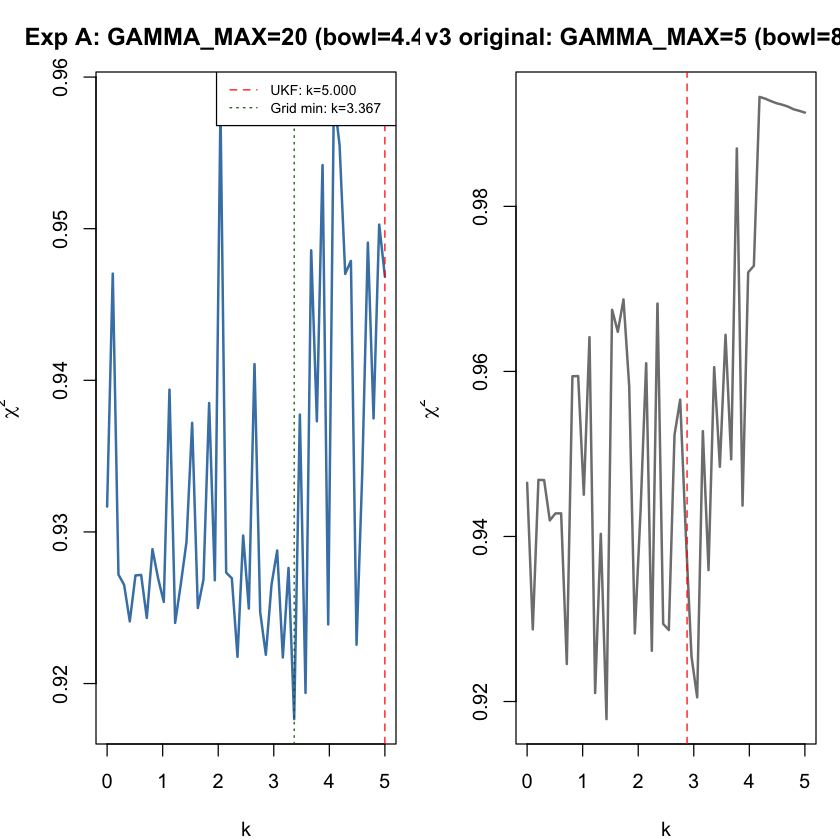

In [17]:
# --- Stage 2: re-run coupling with new gamma estimates -----------------------
log_section("EXP A: COUPLING WITH NEW GAMMA")

gamma_a_new <- expA_h1[["Aralik_avg_spd"]]$gamma
gamma_h_new <- expA_h1[["Igdir_avg_spd"]]$gamma
log_message(sprintf("New Stage 1: Aralik gamma=%.4f (%.1fd), Igdir gamma=%.4f (%.1fd)",
                    gamma_a_new, expA_h1[["Aralik_avg_spd"]]$period,
                    gamma_h_new, expA_h1[["Igdir_avg_spd"]]$period))

valid_both <- !is.na(wind_lho$a_avg_spd) & !is.na(wind_lho$h_avg_spd)
ts_p <- prepare_lho_paired_input(
  wind_lho$a_avg_spd[valid_both], wind_lho$h_avg_spd[valid_both],
  seq_len(sum(valid_both)), dT = WIND_UKF$dT)

paired_new <- make_lho_fixed_ab(gamma_a_new, gamma_h_new, zeta_fixed = 0.1)

t0 <- proc.time()
res_k <- iterative_param_optim(
  param_guess = c(0.1), t_dummy = WIND_UKF$t_dummy, ts_data = ts_p,
  ode_model = paired_new, N_p = 1, N_y = 4,
  dt = WIND_UKF$dt, dT = WIND_UKF$dT,
  R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
  forcePositive = TRUE, seeded = TRUE,
  verbose = TRUE, log_file = file.path("logs", "expA_coupling.csv"),
  param_lower = c(0), param_upper = c(PENDULUM_BOUNDS$K_MAX))
el_k <- (proc.time() - t0)[3]

k_new <- res_k$par[1]
log_fit(res_k, experiment = "ExpA_coupling", hypothesis = "ExpA",
        station = "Aralik-Igdir", signal_type = "avg_spd", segment = "full",
        model = "LHO_fixed_ab_fz01", N_p = 1, N_y = 4, T_obs = nrow(ts_p),
        param_names = c("k"), elapsed_sec = el_k,
        notes = sprintf("GAMMA_MAX=20, a=%.4f, b=%.4f", gamma_a_new, gamma_h_new))

log_message(sprintf("Coupling: k=%.4f (v3 was k=%.4f)", k_new, 2.8792))

# Chi-sq surface
log_message("Chi2 surface scan (Exp A)...")
k_grid_A <- seq(0, PENDULUM_BOUNDS$K_MAX, length.out = 50)
chi2_A <- numeric(length(k_grid_A))
for (i in seq_along(k_grid_A)) {
  run <- UKF_blend(WIND_UKF$t_dummy, ts_p, paired_new,
                    1, 4, k_grid_A[i], WIND_UKF$dt, WIND_UKF$dT,
                    WIND_UKF$R_scale, WIND_UKF$Q_scale,
                    forcePositive = TRUE, seeded = TRUE)
  chi2_A[i] <- run$chisq
}
bowl_A <- max(chi2_A) - min(chi2_A)
bowl_pct_A <- bowl_A / min(chi2_A) * 100
k_min_A <- k_grid_A[which.min(chi2_A)]
log_chi2_surface(k_grid_A, chi2_A, "ExpA_coupling_newgamma", "ExpA")

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
# Exp A surface
plot(k_grid_A, chi2_A, type = "l", lwd = 2, col = "steelblue",
     xlab = "k", ylab = expression(chi^2),
     main = sprintf("Exp A: GAMMA_MAX=20 (bowl=%.2f%%)", bowl_pct_A))
abline(v = k_new, col = "red", lty = 2)
abline(v = k_min_A, col = "darkgreen", lty = 3)
legend("topright", c(sprintf("UKF: k=%.3f", k_new), sprintf("Grid min: k=%.3f", k_min_A)),
       col = c("red","darkgreen"), lty = c(2,3), cex = 0.7)

# v3 surface for comparison
plot(k_grid, chi2_surface, type = "l", lwd = 2, col = "grey50",
     xlab = "k", ylab = expression(chi^2),
     main = sprintf("v3 original: GAMMA_MAX=5 (bowl=%.2f%%)", bowl_pct))
abline(v = k_est, col = "red", lty = 2)
par(mfrow = c(1, 1))

# Seed sensitivity
log_message("Seed sensitivity (Exp A)...")
k_inits_A <- c(0.01, 0.1, 0.5, 1.0, 2.5)
k_ests_A <- numeric(length(k_inits_A))
for (i in seq_along(k_inits_A)) {
  ri <- iterative_param_optim(
    param_guess = k_inits_A[i], t_dummy = WIND_UKF$t_dummy, ts_data = ts_p,
    ode_model = paired_new, N_p = 1, N_y = 4,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(0), param_upper = c(PENDULUM_BOUNDS$K_MAX))
  k_ests_A[i] <- ri$par[1]
  log_message(sprintf("  k_init=%.2f -> k=%.4f (chi2=%.4f, %d iters)", k_inits_A[i], ri$par[1], ri$value, ri$steps))
}
cv_A <- sd(k_ests_A) / abs(mean(k_ests_A))
log_message(sprintf("CV = %.4f (v3 was 0.001)", cv_A))
log_message(sprintf("VERDICT: %s", ifelse(cv_A < 0.5, "IDENTIFIABLE", "NOT IDENTIFIABLE")))

## Exp B — Cross-Signal Robustness

Run the full LHO two-stage pipeline on all available signal pairs to verify the coupling result isn't specific to avg_spd. Tests:
- Aralik max_spd + Igdir avg_spd
- Aralik avg_spd + Igdir avg_spd (already done — use as reference)
- Each station's max_spd vs avg_spd as a within-station "coupling" check

In [18]:
# =============================================================================
# Exp B: CROSS-SIGNAL ROBUSTNESS
# =============================================================================
log_section("EXP B: CROSS-SIGNAL ROBUSTNESS")

# Use the new GAMMA_MAX for all Stage 1 fits
GM <- GAMMA_MAX_NEW
log_message(sprintf("Using GAMMA_MAX=%.0f for all fits", GM))

# Stage 1 for all signals we might pair
expB_stage1 <- list()
stage1_sigs <- list(
  list(col = "a_avg_spd", label = "Aralik_avg"),
  list(col = "a_max_spd", label = "Aralik_max"),
  list(col = "h_avg_spd", label = "Igdir_avg")
)

for (si in stage1_sigs) {
  # Use Exp A results if available, otherwise fit fresh
  expA_key <- paste0(gsub("_avg$|_max$", "", si$label), "_",
                      ifelse(grepl("avg", si$col), "avg_spd", "max_spd"))
  if (expA_key %in% names(expA_h1)) {
    expB_stage1[[si$label]] <- expA_h1[[expA_key]]$gamma
    log_message(sprintf("  %s: gamma=%.4f (from Exp A)", si$label, expA_h1[[expA_key]]$gamma))
  } else {
    valid <- !is.na(wind_lho[[si$col]])
    ts <- prepare_lho_single_input(wind_lho[[si$col]][valid], seq_len(sum(valid)), dT = WIND_UKF$dT)
    res <- iterative_param_optim(
      param_guess = c(4.0), t_dummy = WIND_UKF$t_dummy, ts_data = ts,
      ode_model = make_lho_single(0.1), N_p = 1, N_y = 2,
      dt = WIND_UKF$dt, dT = WIND_UKF$dT,
      R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
      forcePositive = TRUE, seeded = TRUE,
      param_lower = c(PENDULUM_BOUNDS$GAMMA_MIN), param_upper = c(GM))
    expB_stage1[[si$label]] <- res$par[1]
    log_message(sprintf("  %s: gamma=%.4f (fresh fit)", si$label, res$par[1]))
  }
}



═════════════════════════════════════════════════════════════════
  EXP B: CROSS-SIGNAL ROBUSTNESS
═════════════════════════════════════════════════════════════════
[07:30:50] Using GAMMA_MAX=20 for all fits
[07:30:50]   Aralik_avg: gamma=4.7811 (from Exp A)
[07:30:50]   Aralik_max: gamma=7.2358 (from Exp A)
[07:30:50]   Igdir_avg: gamma=7.1173 (from Exp A)


[07:30:50] 
--- Aralik_avg x Igdir_avg ---
[07:30:50]   gamma_a=4.7811, gamma_b=7.1173
[ExpB] LHO_fixed_ab_fz01 | Aralik_avg x Igdir_avg/paired/full | params=[5] | chi²=0.9279 | 1000 iters | 1157.7s
[07:50:42] Chi² surface [ExpB_Aralik_avg_x_Igdir_avg]: K_best=2.7586, bowl_depth=0.0312, range=[0.9196, 0.9508]
[07:50:42]   k=5.0000, chi2=0.9279, bowl=3.39%, 1000 iters
[07:50:42] 
--- Aralik_max x Igdir_avg ---
[07:50:42]   gamma_a=7.2358, gamma_b=7.1173
[ExpB] LHO_fixed_ab_fz01 | Aralik_max x Igdir_avg/paired/full | params=[0.072949] | chi²=0.9687 | 1000 iters | 1159.2s
[08:10:36] Chi² surface [ExpB_Aralik_max_x_Igdir_avg]: K_best=5.0000, bowl_depth=0.0525, range=[0.9373, 0.9898]
[08:10:36]   k=0.0729, chi2=0.9687, bowl=5.60%, 1000 iters
[08:10:36] 
--- Aralik_avg x Aralik_max ---
[08:10:36]   gamma_a=4.7811, gamma_b=7.2358
[ExpB] LHO_fixed_ab_fz01 | Aralik_avg x Aralik_max/paired/full | params=[1.038383] | chi²=0.9178 | 5 iters | 5.8s
[08:11:17] Chi² surface [ExpB_Aralik_avg_x_Aralik_m

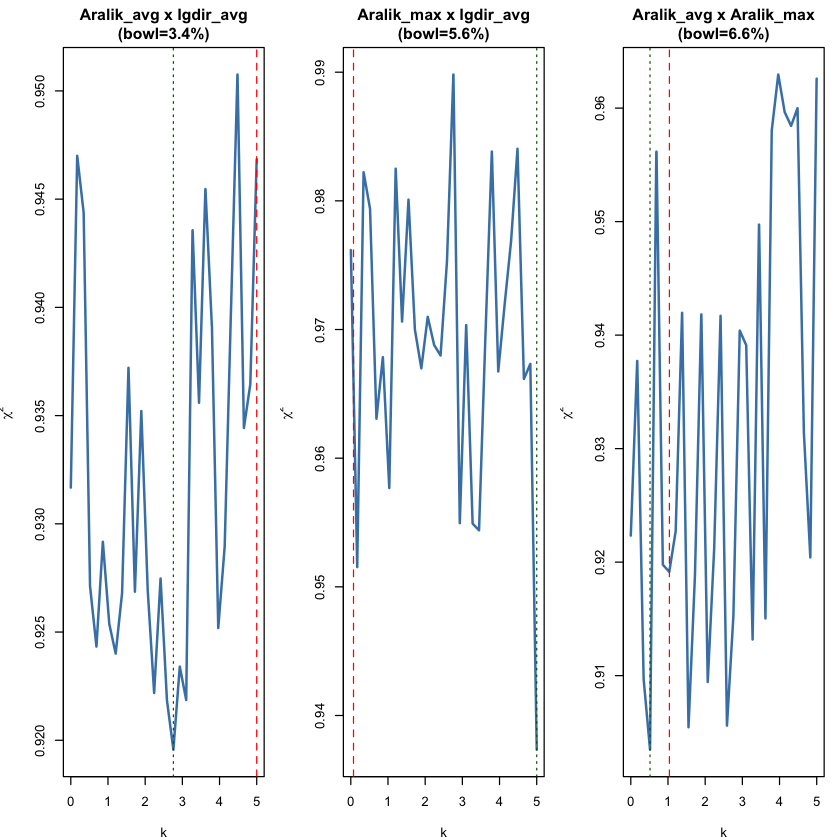

In [19]:
# Stage 2: all interesting pairs
expB_pairs <- list(
  list(s1="Aralik_avg", c1="a_avg_spd", s2="Igdir_avg",  c2="h_avg_spd", label="Aralik_avg x Igdir_avg"),
  list(s1="Aralik_max", c1="a_max_spd", s2="Igdir_avg",  c2="h_avg_spd", label="Aralik_max x Igdir_avg"),
  list(s1="Aralik_avg", c1="a_avg_spd", s2="Aralik_max", c2="a_max_spd", label="Aralik_avg x Aralik_max")
)

expB_results <- list()

for (pr in expB_pairs) {
  log_message(sprintf("\n--- %s ---", pr$label))
  ga <- expB_stage1[[pr$s1]]
  gb <- expB_stage1[[pr$s2]]
  log_message(sprintf("  gamma_a=%.4f, gamma_b=%.4f", ga, gb))

  valid_p <- !is.na(wind_lho[[pr$c1]]) & !is.na(wind_lho[[pr$c2]])
  ts_p <- prepare_lho_paired_input(
    wind_lho[[pr$c1]][valid_p], wind_lho[[pr$c2]][valid_p],
    seq_len(sum(valid_p)), dT = WIND_UKF$dT)

  model_p <- make_lho_fixed_ab(ga, gb, zeta_fixed = 0.1)

  t0 <- proc.time()
  res_p <- iterative_param_optim(
    param_guess = c(0.1), t_dummy = WIND_UKF$t_dummy, ts_data = ts_p,
    ode_model = model_p, N_p = 1, N_y = 4,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(0), param_upper = c(PENDULUM_BOUNDS$K_MAX))
  el_p <- (proc.time() - t0)[3]

  k_p <- res_p$par[1]
  log_fit(res_p, experiment = "ExpB_cross_signal", hypothesis = "ExpB",
          station = pr$label, signal_type = "paired", segment = "full",
          model = "LHO_fixed_ab_fz01", N_p = 1, N_y = 4, T_obs = nrow(ts_p),
          param_names = c("k"), elapsed_sec = el_p,
          notes = sprintf("a=%.4f, b=%.4f", ga, gb))

  # Chi-sq surface
  k_gr <- seq(0, PENDULUM_BOUNDS$K_MAX, length.out = 30)
  chi2_p <- numeric(length(k_gr))
  for (i in seq_along(k_gr)) {
    run <- UKF_blend(WIND_UKF$t_dummy, ts_p, model_p,
                      1, 4, k_gr[i], WIND_UKF$dt, WIND_UKF$dT,
                      WIND_UKF$R_scale, WIND_UKF$Q_scale,
                      forcePositive = TRUE, seeded = TRUE)
    chi2_p[i] <- run$chisq
  }
  bowl_p <- (max(chi2_p) - min(chi2_p)) / min(chi2_p) * 100
  log_chi2_surface(k_gr, chi2_p, sprintf("ExpB_%s", gsub(" ", "_", pr$label)), "ExpB")

  expB_results[[pr$label]] <- list(k = k_p, chisq = res_p$value, bowl_pct = bowl_p,
                                    gamma_a = ga, gamma_b = gb, iters = res_p$steps,
                                    k_grid = k_gr, chi2_surf = chi2_p)

  log_message(sprintf("  k=%.4f, chi2=%.4f, bowl=%.2f%%, %d iters",
                      k_p, res_p$value, bowl_p, res_p$steps))
}

# Summary
log_section("EXP B: CROSS-SIGNAL SUMMARY")
cat("\n+-------------------------------+--------+--------+---------+------+
")
cat(  "| Pair                          |   k    |  chi2  | bowl %  | iter |
")
cat(  "+-------------------------------+--------+--------+---------+------+
")
for (nm in names(expB_results)) {
  r <- expB_results[[nm]]
  cat(sprintf("| %-29s | %6.4f | %6.4f | %6.2f%% | %4d |
",
              nm, r$k, r$chisq, r$bowl_pct, r$iters))
}
cat("+-------------------------------+--------+--------+---------+------+
")

# Plot all surfaces side by side
par(mfrow = c(1, length(expB_results)), mar = c(4, 4, 3, 1))
for (nm in names(expB_results)) {
  r <- expB_results[[nm]]
  plot(r$k_grid, r$chi2_surf, type = "l", lwd = 2, col = "steelblue",
       xlab = "k", ylab = expression(chi^2),
       main = sprintf("%s\n(bowl=%.1f%%)", nm, r$bowl_pct))
  abline(v = r$k, col = "red", lty = 2)
  abline(v = r$k_grid[which.min(r$chi2_surf)], col = "darkgreen", lty = 3)
}
par(mfrow = c(1, 1))

## Exp C — Zeta Sensitivity at Unconstrained Gamma

Re-run the zeta sensitivity analysis with GAMMA_MAX=20 to check whether the k-zeta confound persists when gamma is unconstrained.



═════════════════════════════════════════════════════════════════
  EXP C: ZETA SENSITIVITY (GAMMA_MAX=20)
═════════════════════════════════════════════════════════════════
[08:36:59]   zeta=0.01: gamma_a=9.948 gamma_h=9.851 k=0.0424 chi2_k=1.0647
[09:28:35]   zeta=0.05: gamma_a=9.803 gamma_h=9.330 k=0.4405 chi2_k=1.0680
[09:52:49]   zeta=0.10: gamma_a=4.781 gamma_h=7.117 k=5.0000 chi2_k=0.9279
[10:18:55]   zeta=0.20: gamma_a=5.191 gamma_h=6.223 k=0.2897 chi2_k=0.9346
[10:19:12]   zeta=0.50: gamma_a=3.901 gamma_h=3.874 k=0.1359 chi2_k=1.0681
[10:44:51]   zeta=1.00: gamma_a=1.198 gamma_h=1.581 k=0.5279 chi2_k=1.0676


═════════════════════════════════════════════════════════════════
  EXP C: ZETA SENSITIVITY SUMMARY
═════════════════════════════════════════════════════════════════

+---------+---------+---------+--------+---------+
|  zeta   | gamma_a | gamma_h |    k   | chi2_k  |
+---------+---------+---------+--------+---------+
|    0.01 |   9.948 |   9.851 | 0.0424 |  1.0647 |
| 

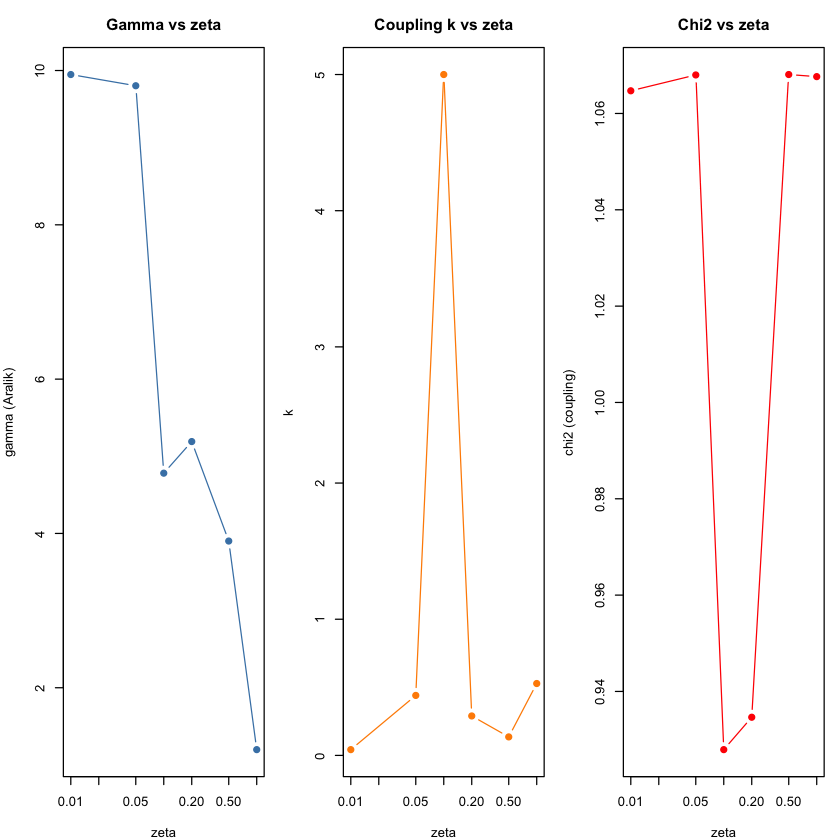

In [20]:
# =============================================================================
# Exp C: ZETA SENSITIVITY AT NEW GAMMA
# =============================================================================
log_section("EXP C: ZETA SENSITIVITY (GAMMA_MAX=20)")

zeta_vals <- c(0.01, 0.05, 0.10, 0.20, 0.50, 1.00)
expC_results <- data.frame(zeta = numeric(), gamma_a = numeric(), gamma_h = numeric(),
                            k = numeric(), chisq_s1a = numeric(), chisq_k = numeric())

for (z in zeta_vals) {
  # Stage 1 for each zeta
  valid_a <- !is.na(wind_lho$a_avg_spd)
  ts_a <- prepare_lho_single_input(wind_lho$a_avg_spd[valid_a], seq_len(sum(valid_a)), dT = WIND_UKF$dT)
  ra <- iterative_param_optim(
    param_guess = c(4.0), t_dummy = WIND_UKF$t_dummy, ts_data = ts_a,
    ode_model = make_lho_single(z), N_p = 1, N_y = 2,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(PENDULUM_BOUNDS$GAMMA_MIN), param_upper = c(GAMMA_MAX_NEW))

  valid_h <- !is.na(wind_lho$h_avg_spd)
  ts_h <- prepare_lho_single_input(wind_lho$h_avg_spd[valid_h], seq_len(sum(valid_h)), dT = WIND_UKF$dT)
  rh <- iterative_param_optim(
    param_guess = c(4.0), t_dummy = WIND_UKF$t_dummy, ts_data = ts_h,
    ode_model = make_lho_single(z), N_p = 1, N_y = 2,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(PENDULUM_BOUNDS$GAMMA_MIN), param_upper = c(GAMMA_MAX_NEW))

  # Stage 2 with those gamma values
  valid_both <- !is.na(wind_lho$a_avg_spd) & !is.na(wind_lho$h_avg_spd)
  ts_p <- prepare_lho_paired_input(
    wind_lho$a_avg_spd[valid_both], wind_lho$h_avg_spd[valid_both],
    seq_len(sum(valid_both)), dT = WIND_UKF$dT)
  model_z <- make_lho_fixed_ab(ra$par[1], rh$par[1], zeta_fixed = z)

  rk <- iterative_param_optim(
    param_guess = c(0.1), t_dummy = WIND_UKF$t_dummy, ts_data = ts_p,
    ode_model = model_z, N_p = 1, N_y = 4,
    dt = WIND_UKF$dt, dT = WIND_UKF$dT,
    R_scale = WIND_UKF$R_scale, Q_scale = WIND_UKF$Q_scale,
    forcePositive = TRUE, seeded = TRUE,
    param_lower = c(0), param_upper = c(PENDULUM_BOUNDS$K_MAX))

  expC_results <- rbind(expC_results, data.frame(
    zeta = z, gamma_a = ra$par[1], gamma_h = rh$par[1],
    k = rk$par[1], chisq_s1a = ra$value, chisq_k = rk$value))

  log_message(sprintf("  zeta=%.2f: gamma_a=%.3f gamma_h=%.3f k=%.4f chi2_k=%.4f",
                      z, ra$par[1], rh$par[1], rk$par[1], rk$value))
}

# Display
log_section("EXP C: ZETA SENSITIVITY SUMMARY")
cat("\n+---------+---------+---------+--------+---------+
")
cat(  "|  zeta   | gamma_a | gamma_h |    k   | chi2_k  |
")
cat(  "+---------+---------+---------+--------+---------+
")
for (i in seq_len(nrow(expC_results))) {
  r <- expC_results[i, ]
  cat(sprintf("| %7.2f | %7.3f | %7.3f | %6.4f | %7.4f |
",
              r$zeta, r$gamma_a, r$gamma_h, r$k, r$chisq_k))
}
cat("+---------+---------+---------+--------+---------+
")

# Is k still sensitive to zeta?
k_cv_C <- sd(expC_results$k) / abs(mean(expC_results$k))
gamma_cv_C <- sd(expC_results$gamma_a) / mean(expC_results$gamma_a)
log_message(sprintf("Gamma CV across zeta: %.3f (%s)", gamma_cv_C,
                    ifelse(gamma_cv_C < 0.1, "INSENSITIVE", "SENSITIVE")))
log_message(sprintf("k CV across zeta: %.3f (%s)", k_cv_C,
                    ifelse(k_cv_C < 0.5, "INSENSITIVE", "SENSITIVE")))

# Find best zeta by chi2
best_idx <- which.min(expC_results$chisq_k)
log_message(sprintf("Best chi2 at zeta=%.2f: k=%.4f, chi2=%.4f",
                    expC_results$zeta[best_idx], expC_results$k[best_idx],
                    expC_results$chisq_k[best_idx]))

# Plot
par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))
plot(expC_results$zeta, expC_results$gamma_a, type = "b", pch = 19, col = "steelblue",
     xlab = "zeta", ylab = "gamma (Aralik)", main = "Gamma vs zeta", log = "x")
plot(expC_results$zeta, expC_results$k, type = "b", pch = 19, col = "darkorange",
     xlab = "zeta", ylab = "k", main = "Coupling k vs zeta", log = "x")
plot(expC_results$zeta, expC_results$chisq_k, type = "b", pch = 19, col = "red",
     xlab = "zeta", ylab = "chi2 (coupling)", main = "Chi2 vs zeta", log = "x")
par(mfrow = c(1, 1))

In [21]:
# =============================================================================
# SAVE FOLLOW-UP RESULTS
# =============================================================================
log_section("FOLLOW-UP EXPERIMENTS COMPLETE")

save(expA_h1, k_new, chi2_A, bowl_pct_A,
     expB_stage1, expB_results,
     expC_results,
     file = "logs/followup_results.RData")

log_message("Follow-up results saved to logs/followup_results.RData")
print_summary()



═════════════════════════════════════════════════════════════════
  FOLLOW-UP EXPERIMENTS COMPLETE
═════════════════════════════════════════════════════════════════
[10:44:51] Follow-up results saved to logs/followup_results.RData


═════════════════════════════════════════════════════════════════
  EXPERIMENT SUMMARY  (443.3 minutes elapsed)
═════════════════════════════════════════════════════════════════
[10:44:51] Total fits logged: 57
[10:44:51] Convergence rate: 66.7% (38/57)
[10:44:51] Mean chi²: 0.7761  (SD: 0.2041)
[10:44:51]   H1: 3 fits, mean chi²=0.7020, converged=3/3
[10:44:51]   H2: 1 fits, mean chi²=0.9287, converged=1/1
[10:44:51]   H3: 36 fits, mean chi²=0.7700, converged=24/36
[10:44:51]   H4: 9 fits, mean chi²=0.7613, converged=6/9
[10:44:51]   H7: 1 fits, mean chi²=0.7791, converged=0/1
[10:44:51]   ExpA: 4 fits, mean chi²=0.7589, converged=3/4
[10:44:51]   ExpB: 3 fits, mean chi²=0.9381, converged=1/3


# Plot Generation

In [22]:
# =============================================================================
# FIGURE 2: Raw data overview (4-panel time series)
# =============================================================================
png("plots/fig2_raw_timeseries.png", width = 2400, height = 1600, res = 200)
par(mfrow = c(2, 2), mar = c(4, 4, 2.5, 1), oma = c(0, 0, 2, 0))

labels_nice <- c("Aralik Avg Speed", "Aralik Max Speed",
                  "Igdir Avg Speed", "Igdir Max Speed")
cols_raw <- c("a_avg_spd", "a_max_spd", "h_avg_spd", "h_max_spd")

for (i in seq_along(cols_raw)) {
  vals <- raw_df[[cols_raw[i]]]
  plot(raw_df$date, vals, type = "l", col = "steelblue", lwd = 0.5,
       xlab = "Date", ylab = "Wind speed (m/s)",
       main = labels_nice[i], cex.main = 0.95)
  na_idx <- which(is.na(vals))
  if (length(na_idx) > 0) {
    na_dates <- raw_df$date[na_idx]
    rug(na_dates, col = adjustcolor("red", 0.3), lwd = 0.3)
  }
}
mtext("Daily Wind Speed Records (2014-2022)", outer = TRUE, cex = 1.1, font = 2)
dev.off()
cat("Saved: plots/fig2_raw_timeseries.png\n")

agg_record_1097754003 
                    2

Saved: plots/fig2_raw_timeseries.png


In [23]:
# =============================================================================
# FIGURE 3: Spectral analysis (4-panel)
# =============================================================================
png("plots/fig3_spectral.png", width = 2400, height = 1600, res = 200)
par(mfrow = c(2, 2), mar = c(4, 4, 2.5, 1), oma = c(0, 0, 2, 0))

for (i in seq_along(cols_raw)) {
  sig <- wind_lho[[cols_raw[i]]]
  sig <- sig[is.finite(sig)]
  n <- length(sig)
  if (n < 20) { plot.new(); next }

  sp <- Mod(fft(sig - mean(sig)))[2:(n %/% 2 + 1)]^2
  freqs <- (1:(n %/% 2)) / (n * 1.0)
  periods <- 1 / freqs

  plot(periods, sp, type = "l", log = "x", xlim = c(2, 400), col = "steelblue",
       xlab = "Period (days)", ylab = "Power", main = labels_nice[i], cex.main = 0.95)

  abline(v = 365.25, col = "red", lty = 2, lwd = 0.8)
  abline(v = 182.6, col = "blue", lty = 2, lwd = 0.8)
  abline(v = 7, col = "darkgreen", lty = 2, lwd = 0.8)

  # Mark synoptic peak
  idx_syn <- which(freqs >= 1/30 & freqs <= 1/3)
  if (length(idx_syn) > 0) {
    f_peak <- freqs[idx_syn[which.max(sp[idx_syn])]]
    abline(v = 1/f_peak, col = "darkorange", lwd = 1.5)
    legend("topright", sprintf("Peak: %.1f d", 1/f_peak), col = "darkorange",
           lwd = 1.5, cex = 0.65, bty = "n")
  }
}
mtext("Power Spectral Density (broadband signal)", outer = TRUE, cex = 1.1, font = 2)
dev.off()
cat("Saved: plots/fig3_spectral.png\n")

agg_record_1482145824 
                    2

Saved: plots/fig3_spectral.png


In [24]:
# =============================================================================
# FIGURE 4: H1 gamma summary — v3 vs Exp A
# =============================================================================
png("plots/fig4_h1_gamma.png", width = 2000, height = 1200, res = 200)
par(mar = c(5, 5, 3, 5))

sig_names <- c("Aralik avg", "Aralik max", "Igdir avg")
gamma_v3 <- c(h1_results[["Aralik_avg_spd"]]$gamma,
              h1_results[["Aralik_max_spd"]]$gamma,
              h1_results[["Igdir_avg_spd"]]$gamma)
gamma_A <- c(expA_h1[["Aralik_avg_spd"]]$gamma,
             expA_h1[["Aralik_max_spd"]]$gamma,
             expA_h1[["Igdir_avg_spd"]]$gamma)

bp <- barplot(rbind(gamma_v3, gamma_A), beside = TRUE,
              names.arg = sig_names,
              col = c("steelblue", "darkorange"),
              ylim = c(0, max(gamma_A) * 1.25),
              ylab = expression(gamma ~ "(rad"^2*"/day"^2*")"),
              main = "Single-Station Natural Frequency Estimates",
              cex.names = 0.9, border = NA)

# Period labels on top of bars
for (i in 1:3) {
  text(bp[1, i], gamma_v3[i] + 0.3, sprintf("%.1fd", 2*pi/sqrt(gamma_v3[i])), cex = 0.65)
  text(bp[2, i], gamma_A[i] + 0.3, sprintf("%.1fd", 2*pi/sqrt(gamma_A[i])), cex = 0.65)
}

# Ceiling line
abline(h = 5.0, col = "red", lty = 2, lwd = 1)
text(bp[1,3] + 1, 5.2, expression(gamma[MAX]*" = 5.0 (v3)"), col = "red", cex = 0.65, adj = 0)

legend("topleft", c(expression("v3 ("*gamma[MAX]*"=5)"), expression("Exp A ("*gamma[MAX]*"=20)")),
       fill = c("steelblue", "darkorange"), border = NA, cex = 0.75)

# Right y-axis: period
axis(4, at = c(1, 2, 4, 7, 10), labels = sprintf("%.1f", 2*pi/sqrt(c(1,2,4,7,10))),
     cex.axis = 0.75, las = 1)
mtext("Period (days)", side = 4, line = 3, cex = 0.85)
dev.off()
cat("Saved: plots/fig4_h1_gamma.png\n")

agg_record_1762774266 
                    2

Saved: plots/fig4_h1_gamma.png


In [25]:
# =============================================================================
# FIGURE 5: Chi-squared surface comparison (3-panel)
# =============================================================================
png("plots/fig5_chisq_surfaces.png", width = 3000, height = 1000, res = 200)
par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))

# Panel (a): v3 GAMMA_MAX=5
plot(k_grid, chi2_surface, type = "l", lwd = 2, col = "steelblue",
     xlab = "Coupling k", ylab = expression(chi^2),
     main = sprintf("(a) v3: GAMMA_MAX=5\nBowl=%.1f%%, CV=0.001", bowl_pct))
abline(v = k_est, col = "red", lty = 2, lwd = 1.5)
abline(v = k_grid[which.min(chi2_surface)], col = "darkgreen", lty = 3)
legend("topright", c(sprintf("UKF: k=%.2f", k_est),
       sprintf("Grid min: k=%.2f", k_grid[which.min(chi2_surface)])),
       col = c("red", "darkgreen"), lty = c(2,3), cex = 0.6, bty = "n")

# Panel (b): Exp A GAMMA_MAX=20
plot(k_grid_A, chi2_A, type = "l", lwd = 2, col = "darkorange",
     xlab = "Coupling k", ylab = expression(chi^2),
     main = sprintf("(b) Exp A: GAMMA_MAX=20\nBowl=%.1f%%", bowl_pct_A))
abline(v = k_new, col = "red", lty = 2, lwd = 1.5)
k_min_A <- k_grid_A[which.min(chi2_A)]
abline(v = k_min_A, col = "darkgreen", lty = 3)
legend("topright", c(sprintf("UKF: k=%.2f [boundary]", k_new),
       sprintf("Grid min: k=%.2f", k_min_A)),
       col = c("red", "darkgreen"), lty = c(2,3), cex = 0.6, bty = "n")

# Panel (c): Within-station positive control (Exp B)
r_ws <- expB_results[["Aralik_avg x Aralik_max"]]
plot(r_ws$k_grid, r_ws$chi2_surf, type = "l", lwd = 2, col = "purple",
     xlab = "Coupling k", ylab = expression(chi^2),
     main = sprintf("(c) Within-station control\nBowl=%.1f%%, converged in 5 iters", r_ws$bowl_pct))
abline(v = r_ws$k, col = "red", lty = 2, lwd = 1.5)
abline(v = r_ws$k_grid[which.min(r_ws$chi2_surf)], col = "darkgreen", lty = 3)
legend("topright", c(sprintf("UKF: k=%.2f", r_ws$k)),
       col = "red", lty = 2, cex = 0.6, bty = "n")

dev.off()
cat("Saved: plots/fig5_chisq_surfaces.png\n")

agg_record_1142341881 
                    2

Saved: plots/fig5_chisq_surfaces.png


In [26]:
# =============================================================================
# FIGURE 6: Seasonal gamma boxplots
# =============================================================================
png("plots/fig6_seasonal_gamma.png", width = 2200, height = 1200, res = 200)
par(mfrow = c(1, 2), mar = c(4, 4.5, 3, 1))

season_order <- c("winter", "spring", "summer", "autumn")
h3_df$season_f <- factor(h3_df$season, levels = season_order)
cols_season <- c("#4A90D9", "#66BB6A", "#FFA726", "#EF5350")

boxplot(gamma ~ season_f, data = h3_df, col = cols_season,
        xlab = "Season", ylab = expression(gamma ~ "(rad"^2*"/day"^2*")"),
        main = expression("(a) Seasonal " * gamma), cex.main = 1,
        outline = TRUE, pch = 16, cex = 0.6)
stripchart(gamma ~ season_f, data = h3_df, method = "jitter", jitter = 0.15,
           add = TRUE, pch = 16, cex = 0.5, col = adjustcolor("black", 0.4),
           vertical = TRUE)
kw_text <- sprintf("KW H=%.2f, p=%.3f", 5.723, 0.126)
mtext(kw_text, side = 3, line = -1.5, cex = 0.65, adj = 0.98)

boxplot(period ~ season_f, data = h3_df, col = cols_season,
        xlab = "Season", ylab = "Period (days)",
        main = "(b) Seasonal oscillation period", cex.main = 1,
        outline = TRUE, pch = 16, cex = 0.6)
stripchart(period ~ season_f, data = h3_df, method = "jitter", jitter = 0.15,
           add = TRUE, pch = 16, cex = 0.5, col = adjustcolor("black", 0.4),
           vertical = TRUE)

dev.off()
cat("Saved: plots/fig6_seasonal_gamma.png\n")

agg_record_1670912302 
                    2

Saved: plots/fig6_seasonal_gamma.png


In [27]:
# =============================================================================
# FIGURE 7: Yearly gamma trajectory
# =============================================================================
png("plots/fig7_yearly_gamma.png", width = 2000, height = 1000, res = 200)
par(mfrow = c(1, 2), mar = c(4, 4.5, 3, 1))

plot(h4_df$year, h4_df$gamma, type = "b", pch = 19, col = "steelblue", lwd = 1.5,
     xlab = "Year", ylab = expression(gamma ~ "(rad"^2*"/day"^2*")"),
     main = "(a) Yearly gamma estimates", ylim = c(0, max(h4_df$gamma) * 1.15))
trend4 <- lm(gamma ~ year, data = h4_df)
abline(trend4, col = "red", lty = 2)
p_val <- summary(trend4)$coefficients[2, 4]
mtext(sprintf("slope=%.3f/yr, p=%.3f", coef(trend4)[2], p_val), side = 3, line = -1.5,
      cex = 0.65, adj = 0.98)
# Highlight 2016-2017 dip
rect(2015.5, -0.5, 2017.5, max(h4_df$gamma) * 1.1,
     col = adjustcolor("yellow", 0.15), border = NA)

plot(h4_df$year, h4_df$period, type = "b", pch = 19, col = "darkorange", lwd = 1.5,
     xlab = "Year", ylab = "Period (days)", main = "(b) Yearly oscillation period")
rect(2015.5, 0, 2017.5, max(h4_df$period) * 1.1,
     col = adjustcolor("yellow", 0.15), border = NA)

dev.off()
cat("Saved: plots/fig7_yearly_gamma.png\n")

agg_record_1100098703 
                    2

Saved: plots/fig7_yearly_gamma.png


In [28]:
# =============================================================================
# FIGURE 8: Zeta sensitivity (Exp C)
# =============================================================================
png("plots/fig8_zeta_sensitivity.png", width = 3000, height = 1000, res = 200)
par(mfrow = c(1, 3), mar = c(4, 4.5, 3, 1))

plot(expC_results$zeta, expC_results$gamma_a, type = "b", pch = 19, col = "steelblue",
     log = "x", xlab = expression(zeta), ylab = expression(gamma[Aralik]),
     main = expression("(a) " * gamma * " vs " * zeta), lwd = 1.5)
points(expC_results$zeta, expC_results$gamma_h, type = "b", pch = 17, col = "darkorange", lwd = 1.5)
legend("topright", c("Aralik avg", "Igdir avg"), pch = c(19, 17),
       col = c("steelblue", "darkorange"), cex = 0.7, bty = "n")
gamma_cv <- sd(expC_results$gamma_a) / mean(expC_results$gamma_a)
mtext(sprintf("CV(gamma_a)=%.2f", gamma_cv), side = 3, line = -1.5, cex = 0.6, adj = 0.98)

plot(expC_results$zeta, expC_results$k, type = "b", pch = 19, col = "red",
     log = "x", xlab = expression(zeta), ylab = "Coupling k",
     main = expression("(b) k vs " * zeta), lwd = 1.5)
abline(h = 5.0, col = "grey50", lty = 3)
text(0.5, 4.7, "K_MAX boundary", cex = 0.6, col = "grey50")
k_cv_C <- sd(expC_results$k) / abs(mean(expC_results$k))
mtext(sprintf("CV(k)=%.2f", k_cv_C), side = 3, line = -1.5, cex = 0.6, adj = 0.98)

plot(expC_results$zeta, expC_results$chisq_k, type = "b", pch = 19, col = "purple",
     log = "x", xlab = expression(zeta), ylab = expression(chi^2 ~ "(coupling stage)"),
     main = expression("(c) " * chi^2 * " vs " * zeta), lwd = 1.5)
best_z <- expC_results$zeta[which.min(expC_results$chisq_k)]
abline(v = best_z, col = "darkgreen", lty = 2)
text(best_z * 1.3, max(expC_results$chisq_k) * 0.98,
     sprintf("Best: zeta=%.2f", best_z), cex = 0.6, col = "darkgreen", adj = 0)

dev.off()
cat("Saved: plots/fig8_zeta_sensitivity.png\n")

agg_record_1967484005 
                    2

Saved: plots/fig8_zeta_sensitivity.png


In [29]:
# =============================================================================
# FIGURE 9: Cross-signal coupling surfaces (Exp B)
# =============================================================================
png("plots/fig9_cross_signal.png", width = 3000, height = 1000, res = 200)
par(mfrow = c(1, 3), mar = c(4, 4.5, 3, 1))

pair_names <- c("Aralik_avg x Igdir_avg", "Aralik_max x Igdir_avg", "Aralik_avg x Aralik_max")
pair_labels <- c("(a) Inter-station (avg x avg)", "(b) Inter-station (max x avg)", "(c) Within-station (positive ctrl)")
pair_cols <- c("steelblue", "darkorange", "purple")

for (j in seq_along(pair_names)) {
  r <- expB_results[[pair_names[j]]]
  plot(r$k_grid, r$chi2_surf, type = "l", lwd = 2, col = pair_cols[j],
       xlab = "Coupling k", ylab = expression(chi^2),
       main = sprintf("%s\nk=%.3f, bowl=%.1f%%", pair_labels[j], r$k, r$bowl_pct))
  abline(v = r$k, col = "red", lty = 2, lwd = 1.5)
  k_min_j <- r$k_grid[which.min(r$chi2_surf)]
  abline(v = k_min_j, col = "darkgreen", lty = 3)

  conv_txt <- ifelse(r$iters <= 10, sprintf("Converged (%d iters)", r$iters),
                     sprintf("Non-conv (%d iters)", r$iters))
  legend("topright", conv_txt, cex = 0.6, bty = "n")
}

dev.off()
cat("Saved: plots/fig9_cross_signal.png\n")

agg_record_335173672 
                   2

Saved: plots/fig9_cross_signal.png


In [30]:
# =============================================================================
# FIGURE 10: Cross-domain SL comparison
# =============================================================================
png("plots/fig10_cross_domain.png", width = 1600, height = 1200, res = 200)
par(mar = c(5, 5, 3, 1))

a_values <- c(-1.284, -0.290)
bar_cols <- c("steelblue", "#EF5350")
bp <- barplot(a_values, names.arg = c("Wind synoptic
(this study)", "BOLD MDD
(Kingsbury et al.)"),
              col = bar_cols, border = NA, ylim = c(-1.6, 0.3),
              ylab = "SL bifurcation parameter (a)",
              main = "Cross-Domain Dynamical Regime Comparison")
abline(h = 0, col = "black", lwd = 1.5)
text(bp, a_values - 0.08, sprintf("a = %.3f", a_values), cex = 0.8, font = 2)

# Regime labels
text(mean(bp), 0.15, "CRITICAL (a = 0)", cex = 0.7, col = "grey30")
arrows(bp[1] - 0.3, -0.05, bp[1] - 0.3, -1.0, length = 0.08, col = "grey50")
text(bp[1] - 0.3, -1.1, "More subcritical", cex = 0.6, col = "grey50")

dev.off()
cat("Saved: plots/fig10_cross_domain.png\n")

agg_record_1413872381 
                    2

Saved: plots/fig10_cross_domain.png


In [32]:
# =============================================================================
# PLOT GENERATION COMPLETE
# =============================================================================
plot_files <- list.files("plots", pattern = "\\.png$", full.names = TRUE)
cat(sprintf("\nGenerated %d plots:\n", length(plot_files)))
for (f in plot_files) cat(sprintf("  %s (%.0f KB)\n", f, file.info(f)$size / 1024))


Generated 9 plots:
  plots/fig10_cross_domain.png (95 KB)
  plots/fig2_raw_timeseries.png (788 KB)
  plots/fig3_spectral.png (263 KB)
  plots/fig4_h1_gamma.png (105 KB)
  plots/fig5_chisq_surfaces.png (373 KB)
  plots/fig6_seasonal_gamma.png (118 KB)
  plots/fig7_yearly_gamma.png (137 KB)
  plots/fig8_zeta_sensitivity.png (202 KB)
  plots/fig9_cross_signal.png (340 KB)
